# ML Pipeline: Predicting Citation Impact

**Objective**: Build a modular ML pipeline to predict citation impact for publications using multiple models and interpretability methods.

**Target Variable**: `citations_first_2y_exact` (regression task, exact citations from publication day to +730 days via OpenAlex API).

**Additional exact targets**:
- `citations_year_1_exact`: citations from publication day to day 365.
- `citations_year_2_exact`: citations from day 366 to day 730.
- `normalized_2y_cites_exact`: compatibility alias of `citations_first_2y_exact`.

**Dataset**: `New_work/data/openalex_output/works.csv` (processed from raw OpenAlex export + exact citation enrichment).

**Approach**:
1. **Baseline**: Linear & Negative Binomial Regression
2. **Main Models**: XGBoost, LightGBM, CatBoost (with 2 train-test strategies: random, stratified)
3. **Interpretability**: SHAP values on top of gradient boosted models
4. **Validation**: Random Forest as parallel model for feature importance cross-check

**Pipeline Structure**: Clear separation of concerns-load -> prepare -> exact target enrichment -> baseline -> main models -> interpret -> validate -> summarize

In [170]:
## Section 1: Setup & Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Gradient boosted models
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Interpretability
import shap

# Statsmodels for Negative Binomial Regression
import statsmodels.api as sm
from statsmodels.genmod.families import NegativeBinomial
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from pathlib import Path

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configure matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All imports successful")

✓ All imports successful


## Section 2: Data Loading & Inspection

In [171]:
# Load and process OpenAlex works data

data_path = Path("/home/ramir713/repos/PublicationAnalysis/data/machine_learning_data/data_ready_for_ml")
df_processed = pd.read_csv(data_path, low_memory=False)
df_processed.columns

Index(['openalex_id', 'openalex_url', 'doi', 'title', 'publication_year',
       'publication_date', 'type', 'cited_by_count', 'fwci',
       'citation_percentile_value', 'cited_by_api_url', 'authors_count',
       'countries_distinct_count', 'institutions_distinct_count',
       'corresponding_author_ids', 'corresponding_institution_ids',
       'queried_author_id', 'queried_author_position',
       'queried_author_is_corresponding', 'queried_author_raw_name',
       'queried_author_raw_affiliation', 'is_oa', 'oa_status', 'source_id',
       'source_display_name', 'source_issn_l', 'source_issn', 'source_type',
       'source_is_oa', 'source_host_org_name', 'apc_list_value_usd',
       'apc_paid_value_usd', 'primary_topic_id', 'primary_topic_name',
       'primary_topic_score', 'primary_subfield_id', 'primary_subfield_name',
       'primary_field_id', 'primary_field_name', 'all_topics', 'keywords',
       'sustainable_development_goals', 'referenced_works_count',
       'referenced_wor

In [ ]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from pathlib import Path
import time
import random

def get_exact_2y_cites(
    df_processed,
    id_col="openalex_id",
    date_col="publication_date",
    email=None,
    sleep=0.12,
    checkpoint_path=None,
    save_every=100,
    timeout=20,
    max_retries=4,
):
    """
    Compute exact citation windows per paper using OpenAlex API.

    Appends to df_processed:
      - citations_year_1_exact: from publication day to +364 days
      - citations_year_2_exact: from +365 to +729 days
      - citations_first_2y_exact: year_1 + year_2

    Designed for large batches with resume/checkpoint support.
    """

    base_url = "https://api.openalex.org/works"
    session = requests.Session()
    user_agent = f"mailto:{email}" if email else "OpenAlex-Exact2Y-Citations"
    session.headers.update({"User-Agent": user_agent})

    def _normalize_work_id(work_id):
        s = str(work_id).strip()
        if s.startswith("http"):
            s = s.rstrip("/").split("/")[-1]
        return s

    def _query_count(short_id, from_dt, to_dt):
        params = {
            "filter": f"cites:{short_id},from_publication_date:{from_dt},to_publication_date:{to_dt}",
            "select": "id",
            "per_page": 1,
        }
        if email:
            params["mailto"] = email

        for attempt in range(1, max_retries + 1):
            try:
                resp = session.get(base_url, params=params, timeout=timeout)
                status = resp.status_code
                if status in (429, 500, 502, 503, 504):
                    raise requests.HTTPError(f"HTTP {status}: retryable")
                resp.raise_for_status()
                count = resp.json().get("meta", {}).get("count", 0)
                return int(count) if count is not None else 0
            except Exception as e:
                if attempt == max_retries:
                    print(f"ERROR final ({short_id}): {e}")
                    return np.nan
                backoff = (2 ** (attempt - 1)) * sleep + random.uniform(0, sleep)
                time.sleep(backoff)
        return np.nan

    # Pre-normalize work IDs once for efficient lookups
    work_ids_short = df_processed[id_col].astype(str).map(_normalize_work_id)

    # Resume from checkpoint if available
    cached = {}
    cp = Path(checkpoint_path) if checkpoint_path else None
    if cp and cp.exists():
        cp_df_processed = pd.read_csv(cp)
        required_cache_cols = {
            id_col,
            "citations_year_1_exact",
            "citations_year_2_exact",
            "citations_first_2y_exact",
        }
        if required_cache_cols.issubset(set(cp_df_processed.columns)):
            cp_ids_short = cp_df_processed[id_col].astype(str).map(_normalize_work_id)
            for short_id, y1, y2, total in zip(
                cp_ids_short,
                cp_df_processed["citations_year_1_exact"],
                cp_df_processed["citations_year_2_exact"],
                cp_df_processed["citations_first_2y_exact"],
            ):
                cached[short_id] = (y1, y2, total)
            print(f"Loaded checkpoint with {len(cached)} papers from {cp}")

    results = dict(cached)
    total = len(df_processed)
    processed_now = 0

    for i, (short_id, pub_date_str) in enumerate(zip(work_ids_short, df_processed[date_col]), 1):
        if short_id in results and not any(pd.isna(v) for v in results[short_id]):
            if i % 200 == 0 or i == total:
                print(f"  progress: {i}/{total} (cached/resumed)")
            continue

        try:
            pub_date = datetime.strptime(str(pub_date_str), "%Y-%m-%d")
        except Exception:
            results[short_id] = (np.nan, np.nan, np.nan)
            continue

        y1_start = pub_date
        y1_end = pub_date + timedelta(days=364)
        y2_start = pub_date + timedelta(days=365)
        y2_end = pub_date + timedelta(days=729)

        y1_count = _query_count(short_id, y1_start.strftime("%Y-%m-%d"), y1_end.strftime("%Y-%m-%d"))
        y2_count = _query_count(short_id, y2_start.strftime("%Y-%m-%d"), y2_end.strftime("%Y-%m-%d"))

        if pd.isna(y1_count) or pd.isna(y2_count):
            total_2y = np.nan
        else:
            total_2y = int(y1_count) + int(y2_count)

        results[short_id] = (y1_count, y2_count, total_2y)
        processed_now += 1

        # Save incremental checkpoint for large runs
        if cp and (processed_now % save_every == 0):
            tmp = pd.DataFrame([
                {
                    id_col: k,
                    "citations_year_1_exact": v[0],
                    "citations_year_2_exact": v[1],
                    "citations_first_2y_exact": v[2],
                }
                for k, v in results.items()
            ])
            tmp.to_csv(cp, index=False)
            print(f"  checkpoint saved: {len(tmp)} rows")

        time.sleep(sleep)

        if i % 25 == 0 or i == total:
            print(f"  progress: {i}/{total}")

    lookup = work_ids_short.map(lambda k: results.get(k, (np.nan, np.nan, np.nan)))
    df_processed["citations_year_1_exact"] = lookup.map(lambda v: v[0])
    df_processed["citations_year_2_exact"] = lookup.map(lambda v: v[1])
    df_processed["citations_first_2y_exact"] = lookup.map(lambda v: v[2])

    # Final checkpoint write
    if cp:
        final_cp = pd.DataFrame({
            id_col: work_ids_short,
            "citations_year_1_exact": df_processed["citations_year_1_exact"],
            "citations_year_2_exact": df_processed["citations_year_2_exact"],
            "citations_first_2y_exact": df_processed["citations_first_2y_exact"],
        }).drop_duplicates(subset=[id_col], keep="first")
        final_cp.to_csv(cp, index=False)
        print(f"Final checkpoint saved to {cp}")

    return df_processed

# Apply exact 2-year enrichment (resume-safe for large collections)
checkpoint_file = Path("/home/ramir713/repos/PublicationAnalysis/data/machine_learning_data/data_ready_for_ml")



get_exact_2y_cites(
    df_processed,
    id_col="openalex_id",
    date_col="publication_date",
    email=None,
    sleep=0.12,
    checkpoint_path=checkpoint_file,
    save_every=100,
    timeout=20,
    max_retries=4,
)

# Persist processed dataset for reuse
processed_path = Path("/home/ramir713/repos/PublicationAnalysis/data/machine_learning_data/data_ready_for_ml")
df_processed = df_processed.drop(columns=["Unnamed: 0"], errors="ignore")
df_processed.to_csv(processed_path, index=False)

print("\nExact citation enrichment summary:")
print(df_processed[["citations_year_1_exact", "citations_year_2_exact", "citations_first_2y_exact"]].describe(include="all"))
print(f"Saved processed dataset to: {processed_path}")
print(f'{df_processed.shape}')

Loaded checkpoint with 3959 papers from /home/ramir713/repos/PublicationAnalysis/data/machine_learning_data/data_ready_for_ml
  progress: 200/4268 (cached/resumed)
  progress: 400/4268 (cached/resumed)
  progress: 600/4268 (cached/resumed)
  progress: 800/4268 (cached/resumed)
  progress: 1000/4268 (cached/resumed)
  progress: 1200/4268 (cached/resumed)
  progress: 1400/4268 (cached/resumed)
  progress: 1600/4268 (cached/resumed)
  progress: 1800/4268 (cached/resumed)
  progress: 2000/4268 (cached/resumed)
  progress: 2200/4268 (cached/resumed)
  progress: 2400/4268 (cached/resumed)
  progress: 2600/4268 (cached/resumed)
  progress: 2800/4268 (cached/resumed)
  progress: 3000/4268 (cached/resumed)
  progress: 3200/4268 (cached/resumed)
  progress: 3400/4268 (cached/resumed)
  progress: 3600/4268 (cached/resumed)
  progress: 3800/4268 (cached/resumed)
  progress: 4000/4268 (cached/resumed)
  progress: 4200/4268 (cached/resumed)
  progress: 4268/4268 (cached/resumed)
Final checkpoint sav

In [173]:
df_processed.columns

Index(['openalex_id', 'openalex_url', 'doi', 'title', 'publication_year',
       'publication_date', 'type', 'cited_by_count', 'fwci',
       'citation_percentile_value', 'cited_by_api_url', 'authors_count',
       'countries_distinct_count', 'institutions_distinct_count',
       'corresponding_author_ids', 'corresponding_institution_ids',
       'queried_author_id', 'queried_author_position',
       'queried_author_is_corresponding', 'queried_author_raw_name',
       'queried_author_raw_affiliation', 'is_oa', 'oa_status', 'source_id',
       'source_display_name', 'source_issn_l', 'source_issn', 'source_type',
       'source_is_oa', 'source_host_org_name', 'apc_list_value_usd',
       'apc_paid_value_usd', 'primary_topic_id', 'primary_topic_name',
       'primary_topic_score', 'primary_subfield_id', 'primary_subfield_name',
       'primary_field_id', 'primary_field_name', 'all_topics', 'keywords',
       'sustainable_development_goals', 'referenced_works_count',
       'referenced_wor


TARGET VARIABLE: citations_first_2y_exact
Data type: int64
Null count: 0
Statistics:
count    4268.000000
mean       21.463449
std        40.143115
min         0.000000
25%         5.000000
50%        11.000000
75%        22.000000
max       858.000000
Name: citations_first_2y_exact, dtype: float64

Target distribution:


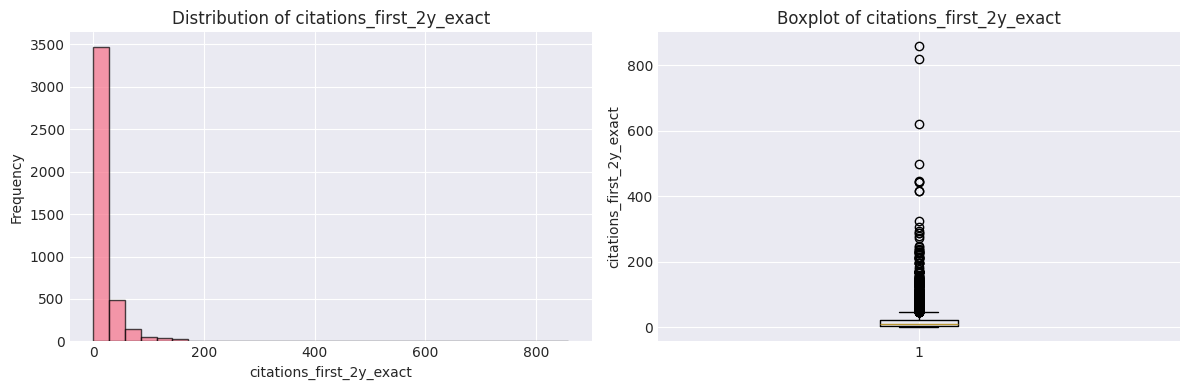

In [174]:
# Inspect target variable
TARGET = "citations_first_2y_exact"  # Exact total citations from day 0 to day 730

print(f"\n{'='*60}")
print(f"TARGET VARIABLE: {TARGET}")
print(f"{'='*60}")
print(f"Data type: {df_processed[TARGET].dtype}")
print(f"Null count: {df_processed[TARGET].isnull().sum()}")
print(f"Statistics:\n{df_processed[TARGET].describe()}")
print(f"\nTarget distribution:")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_processed[TARGET].dropna(), bins=30, edgecolor="black", alpha=0.7)
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Distribution of {TARGET}")
axes[1].boxplot(df_processed[TARGET].dropna(), vert=True)
axes[1].set_ylabel(TARGET)
axes[1].set_title(f"Boxplot of {TARGET}")
plt.tight_layout()
plt.show()

## Section 3: Feature Preparation & Encoding

In [176]:
# Create a clean copy for feature preparation
df_processed_model = df_processed.copy()

# Target for regression (production default: p95-capped exact 2-year citations)
BASE_TARGET = "citations_first_2y_exact"
TARGET = f"{BASE_TARGET}_p95_capped"
LOWER_PERCENTILE = 0.00
UPPER_PERCENTILE = 0.95

if BASE_TARGET not in df_processed_model.columns:
    raise KeyError(f"Base target column '{BASE_TARGET}' is missing from processed dataframe.")

base_target_numeric = pd.to_numeric(df_processed_model[BASE_TARGET], errors="coerce")
if base_target_numeric.isna().all():
    raise ValueError(f"Base target '{BASE_TARGET}' is entirely NaN after numeric coercion.")

p95_upper = base_target_numeric.quantile(UPPER_PERCENTILE)
p95_lower = base_target_numeric.quantile(LOWER_PERCENTILE)
if base_target_numeric.min() <= 0:
    p95_lower = 0.0

df_processed_model[TARGET] = base_target_numeric.clip(lower=p95_lower, upper=p95_upper)

print("=" * 70)
print("TARGET CONFIGURATION")
print("=" * 70)
print(f"Base target: {BASE_TARGET}")
print(f"Modeling target: {TARGET}")
print(f"Cap bounds: [{p95_lower:.2f}, {p95_upper:.2f}] (percentiles {LOWER_PERCENTILE:.0%}-{UPPER_PERCENTILE:.0%})")
print(f"Zero-citation rows kept: {(base_target_numeric == 0).sum()}")
print(f"Upper-tail values capped: {(base_target_numeric > p95_upper).sum()}")

# Drop columns that are IDs, leakage, or non-modeling artifacts when present
columns_to_drop = [
 'openalex_id',
    'openalex_url',
    'title',
    'cited_by_count', 'fwci', 'citation_percentile_value',
    'queried_author_raw_name', 'queried_author_raw_affiliation',
    'source_display_name', 'source_issn_l', 'source_issn',
    'source_host_org_name',
    'primary_topic_name',
    'primary_subfield_name',
    'primary_field_name',
    'all_topics', 'keywords','sdg_names',
    'sustainable_development_goals',
    'referenced_works', 'related_works','apc_paid_value_usd',
    'sdg_names_list','cited_by_api_url','publication_date','primary_topic_score','citations_year_1_exact', 'citations_year_2_exact',
]
df_processed_model.drop(columns=columns_to_drop, inplace=True)

# Separate target from features and remove rows with missing target
target_numeric = pd.to_numeric(df_processed_model[TARGET], errors="coerce")
valid_target_mask = target_numeric.notna()
df_processed_model = df_processed_model.loc[valid_target_mask].copy()
y = target_numeric.loc[valid_target_mask].values

X_raw = df_processed_model.drop(columns=[TARGET, BASE_TARGET] + columns_to_drop, errors="ignore")

# Remove constant columns (can break VIF and add noise)
constant_cols = [c for c in X_raw.columns if X_raw[c].nunique(dropna=False) <= 1]
if constant_cols:
    X_raw = X_raw.drop(columns=constant_cols, errors="ignore")
    print(f"Dropped {len(constant_cols)} constant columns: {constant_cols}")

# Drop columns with >20% missing values
missing_fraction = X_raw.isna().mean()
high_missing_cols = missing_fraction[missing_fraction > 0.20].index.tolist()
if high_missing_cols:
    X_raw = X_raw.drop(columns=high_missing_cols, errors="ignore")
    print(f"Dropped {len(high_missing_cols)} columns with >20% missing: {high_missing_cols}")
else:
    print("No columns dropped for missingness >20%.")

# Keep a raw feature frame for preprocessing pipelines downstream
X_data = X_raw.copy()

print(f"Initial features shape: {X_data.shape}")
print(f"\nFeature columns ({len(X_data.columns)}):")
print(X_data.columns.tolist())

# Column groups for preprocessing
numerical_cols = [c for c in [
    'publication_year',
    'authors_count',
    'countries_distinct_count',
    'institutions_distinct_count',
    'apc_list_value_usd',
    'referenced_works_count',
] if c in X_data.columns]

binary_cols = [c for c in [
    'queried_author_is_corresponding',
    'is_oa',
    'source_is_oa',
] if c in X_data.columns]

id_like_cols = [c for c in [
    'corresponding_author_ids',
    'corresponding_institution_ids',
    'queried_author_id',
    'source_id',
    'primary_topic_id',
    'primary_subfield_id',
    'primary_field_id',
] if c in X_data.columns]

nominal_cols = [c for c in ['type', 'oa_status'] if c in X_data.columns]

position_col = 'queried_author_position'
position_order = ['first', 'middle', 'last']
use_position_ordinal = False
ordinal_cols = []
if position_col in X_data.columns:
    X_data[position_col] = X_data[position_col].astype("string").str.lower()
    position_values = set(X_data[position_col].dropna().unique())
    use_position_ordinal = position_values.issubset(set(position_order))
    if use_position_ordinal:
        ordinal_cols = [position_col]
    else:
        nominal_cols.append(position_col)

nominal_cols = sorted(set(nominal_cols))
string_cols = [c for c in id_like_cols + nominal_cols + ordinal_cols if c in X_data.columns]
if string_cols:
    X_data[string_cols] = X_data[string_cols].astype("string")

categorical_cols = sorted(set(binary_cols + id_like_cols + nominal_cols + ordinal_cols))
X_raw = X_data.copy()

print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"\nBinary columns ({len(binary_cols)}): {binary_cols}")
print(f"\nID-like columns ({len(id_like_cols)}): {id_like_cols}")
print(f"\nNominal columns ({len(nominal_cols)}): {nominal_cols}")
print(f"\nOrdinal columns ({len(ordinal_cols)}): {ordinal_cols}")
print(f"\nqueried_author_position ordinal: {use_position_ordinal}")

TARGET CONFIGURATION
Base target: citations_first_2y_exact
Modeling target: citations_first_2y_exact_p95_capped
Cap bounds: [0.00, 74.65] (percentiles 0%-95%)
Zero-citation rows kept: 190
Upper-tail values capped: 214
Dropped 1 constant columns: ['source_type']
No columns dropped for missingness >20%.
Initial features shape: (4268, 20)

Feature columns (20):
['doi', 'publication_year', 'type', 'authors_count', 'countries_distinct_count', 'institutions_distinct_count', 'corresponding_author_ids', 'corresponding_institution_ids', 'queried_author_id', 'queried_author_position', 'queried_author_is_corresponding', 'is_oa', 'oa_status', 'source_id', 'source_is_oa', 'apc_list_value_usd', 'primary_topic_id', 'primary_subfield_id', 'primary_field_id', 'referenced_works_count']

Categorical columns (13): ['corresponding_author_ids', 'corresponding_institution_ids', 'is_oa', 'oa_status', 'primary_field_id', 'primary_subfield_id', 'primary_topic_id', 'queried_author_id', 'queried_author_is_corresp

PREDICTOR-TARGET CORRELATION DIAGNOSTICS

Top 15 predictors by absolute Pearson correlation with target:
                      Feature  Pearson_r  Spearman_rho  Abs_Pearson_r
       referenced_works_count   0.356910      0.415786       0.356910
     countries_distinct_count   0.329707      0.242103       0.329707
           apc_list_value_usd   0.326353      0.204809       0.326353
                authors_count   0.292559      0.244673       0.292559
  institutions_distinct_count   0.292559      0.244673       0.292559
                         type   0.286738      0.165300       0.286738
                    source_id   0.102659      0.066943       0.102659
                    oa_status   0.092807      0.095024       0.092807
             primary_topic_id  -0.089790     -0.090612       0.089790
             publication_year   0.086220      0.089650       0.086220
                        is_oa   0.079771      0.069329       0.079771
          primary_subfield_id   0.053622      0.058582 

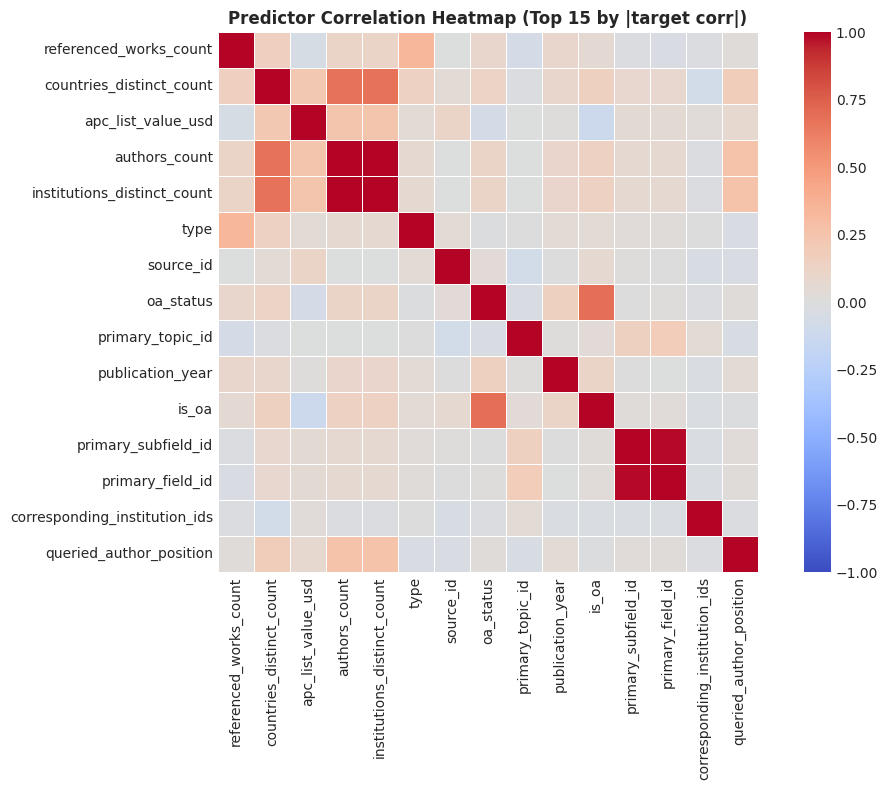


Top VIF values (multicollinearity check):
                      Feature        VIF
                authors_count        inf
  institutions_distinct_count        inf
          primary_subfield_id 161.164883
             primary_field_id 121.423666
             publication_year  43.507347
      queried_author_position   8.945470
           apc_list_value_usd   7.217501
                        is_oa   7.157669
                    oa_status   6.891412
            queried_author_id   4.875224
     countries_distinct_count   4.824488
corresponding_institution_ids   4.816656
     corresponding_author_ids   4.493801
                    source_id   3.726281
       referenced_works_count   3.340615

Predictors with VIF > 10: 5
                    Feature        VIF
              authors_count        inf
institutions_distinct_count        inf
        primary_subfield_id 161.164883
           primary_field_id 121.423666
           publication_year  43.507347

Features marked for removal before mo

In [177]:
# Correlation diagnostics: predictor utility and co-dependence checks
print("=" * 80)
print("PREDICTOR-TARGET CORRELATION DIAGNOSTICS")
print("=" * 80)

# Build an analysis-only numeric matrix (do not modify X_data used later)
corr_X = X_data.copy()

# Numeric columns: coerce and impute median for stable correlations
for col in numerical_cols:
    corr_X[col] = pd.to_numeric(corr_X[col], errors="coerce")
    corr_X[col] = corr_X[col].fillna(corr_X[col].median())

# Categorical columns: encode to integer codes for correlation screening only
for col in categorical_cols:
    corr_X[col] = corr_X[col].astype(str).fillna("MISSING")
    corr_X[col], _ = pd.factorize(corr_X[col], sort=True)

# Ensure fully numeric matrix
corr_X = corr_X.apply(pd.to_numeric, errors="coerce").fillna(0)

# Target as numeric
y_corr = pd.to_numeric(df_processed_model[TARGET], errors="coerce")
valid_rows = y_corr.notna()
corr_X_valid = corr_X.loc[valid_rows].copy()
y_corr_valid = y_corr.loc[valid_rows].copy()

# 1) Predictor vs target correlations (utility)
pearson_vals = corr_X_valid.corrwith(y_corr_valid, method="pearson")
spearman_vals = corr_X_valid.corrwith(y_corr_valid, method="spearman")

feature_target_corr = pd.DataFrame({
    "Feature": corr_X_valid.columns,
    "Pearson_r": pearson_vals.values,
    "Spearman_rho": spearman_vals.values,
})
feature_target_corr["Abs_Pearson_r"] = feature_target_corr["Pearson_r"].abs()
feature_target_corr = feature_target_corr.sort_values("Abs_Pearson_r", ascending=False)

print("\nTop 15 predictors by absolute Pearson correlation with target:")
print(feature_target_corr.head(15).to_string(index=False))

weak_predictors = feature_target_corr[feature_target_corr["Abs_Pearson_r"] < 0.05]
print(f"\nWeak linear-signal predictors (|r| < 0.05): {len(weak_predictors)}")
if len(weak_predictors) > 0:
    print(weak_predictors[["Feature", "Pearson_r"]].head(10).to_string(index=False))

# 2) Predictor co-dependence (pairwise feature correlation)
predictor_corr_abs = corr_X_valid.corr().abs()
upper = predictor_corr_abs.where(np.triu(np.ones(predictor_corr_abs.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature_1", "level_1": "Feature_2", 0: "Abs_r"})
)
high_corr_pairs = high_corr_pairs[high_corr_pairs["Abs_r"] >= 0.80].sort_values("Abs_r", ascending=False)

print(f"\nHighly correlated predictor pairs (|r| >= 0.80): {len(high_corr_pairs)}")
if len(high_corr_pairs) > 0:
    print(high_corr_pairs.head(20).to_string(index=False))
else:
    print("No high-correlation predictor pairs found at this threshold.")

# 3) Heatmap of top utility predictors (helps visual inspection of co-dependence)
top_n_heatmap = 15
top_features = feature_target_corr.head(top_n_heatmap)["Feature"].tolist()
if len(top_features) > 1:
    plt.figure(figsize=(11, 8))
    sns.heatmap(
        corr_X_valid[top_features].corr(),
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
    )
    plt.title(f"Predictor Correlation Heatmap (Top {top_n_heatmap} by |target corr|)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

# 4) VIF (Variance Inflation Factor) for multicollinearity screening
#    Rule of thumb: VIF > 5 moderate concern, VIF > 10 strong concern
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_input = corr_X_valid.copy()
# Remove near-constant columns to avoid numerical issues
vif_input = vif_input.loc[:, vif_input.nunique(dropna=False) > 1]

vif_df_processed = pd.DataFrame({
    "Feature": vif_input.columns,
    "VIF": [variance_inflation_factor(vif_input.values, i) for i in range(vif_input.shape[1])],
}).sort_values("VIF", ascending=False)

print("\nTop VIF values (multicollinearity check):")
print(vif_df_processed.head(15).to_string(index=False))

vif_threshold = 10
high_vif = vif_df_processed[vif_df_processed["VIF"] > vif_threshold]
vif_drop_features = high_vif["Feature"].tolist()

print(f"\nPredictors with VIF > {vif_threshold}: {len(high_vif)}")
if len(high_vif) > 0:
    print(high_vif.to_string(index=False))
    print(f"\nFeatures marked for removal before modeling: {vif_drop_features}")
else:
    print("No features exceed the VIF threshold.")

print("\nInterpretation guide:")
print("- Strong predictor utility: larger |Pearson_r| and/or |Spearman_rho|.")
print("- Potential co-dependence risk: many high-correlation feature pairs and high VIF.")
print("- For coefficient interpretation (linear/GLM), reducing high VIF is usually recommended.")
print("- For pure prediction with tree models, correlated predictors are often less problematic.")

In [178]:
# Apply VIF-based feature reduction (from previous diagnostics cell)
print("Applying VIF-based feature reduction...")
if "vif_drop_features" in globals() and len(vif_drop_features) > 0:
    drop_in_X = [c for c in vif_drop_features if c in X_data.columns]
    X_data = X_data.drop(columns=drop_in_X, errors="ignore")
    print(f"Dropped {len(drop_in_X)} high-VIF features: {drop_in_X}")
else:
    print("No high-VIF features found (or diagnostics cell not run). Proceeding without drops.")

# Sync column groups after VIF drop
numerical_cols = [c for c in numerical_cols if c in X_data.columns]
binary_cols = [c for c in binary_cols if c in X_data.columns]
id_like_cols = [c for c in id_like_cols if c in X_data.columns]
ordinal_cols = [c for c in ordinal_cols if c in X_data.columns]
nominal_cols = [c for c in nominal_cols if c in X_data.columns]
categorical_cols = sorted(set(binary_cols + id_like_cols + nominal_cols + ordinal_cols))
use_position_ordinal = bool(ordinal_cols)

string_cols = [c for c in id_like_cols + nominal_cols + ordinal_cols if c in X_data.columns]
if string_cols:
    X_data[string_cols] = X_data[string_cols].astype("string")

X_raw = X_data.copy()
print(f"Feature matrix ready for preprocessing: {X_raw.shape}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")

Applying VIF-based feature reduction...
Dropped 5 high-VIF features: ['authors_count', 'institutions_distinct_count', 'primary_subfield_id', 'primary_field_id', 'publication_year']
Feature matrix ready for preprocessing: (4268, 15)

Categorical columns (11): ['corresponding_author_ids', 'corresponding_institution_ids', 'is_oa', 'oa_status', 'primary_topic_id', 'queried_author_id', 'queried_author_is_corresponding', 'queried_author_position', 'source_id', 'source_is_oa', 'type']

Numerical columns (3): ['countries_distinct_count', 'apc_list_value_usd', 'referenced_works_count']


## Section 4: Train-Test Split Strategies

Two strategies to understand their trade-offs:
1. **Random 80/20**: Standard random split
2. **Stratified**: Split stratified by a configurable group column (group balance)

In [179]:
# Strategy 1: Random 80/20 Split
print("=" * 70)
print("STRATEGY 1: RANDOM 80/20 SPLIT")
print("=" * 70)
print("Pros: Standard, balanced sampling, reproducible")
print("Cons: May leak temporal patterns if publication year is important")
print("Use: General baseline comparison\n")

X_train_s1_raw, X_test_s1_raw, y_train_s1, y_test_s1 = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True
)

print(f"Training set size: {X_train_s1_raw.shape[0]}")
print(f"Test set size: {X_test_s1_raw.shape[0]}")
print(f"Target distribution in train: mean={y_train_s1.mean():.2f}, std={y_train_s1.std():.2f}")
print(f"Target distribution in test: mean={y_test_s1.mean():.2f}, std={y_test_s1.std():.2f}")

STRATEGY 1: RANDOM 80/20 SPLIT
Pros: Standard, balanced sampling, reproducible
Cons: May leak temporal patterns if publication year is important
Use: General baseline comparison

Training set size: 3414
Test set size: 854
Target distribution in train: mean=17.67, std=19.16
Target distribution in test: mean=17.90, std=19.43


In [180]:
# Strategy 2: Stratified Split (by stable categorical group when available)
print("\n" + "=" * 70)
print("STRATEGY 2: STRATIFIED SPLIT (Group-balanced split)")
print("=" * 70)
print("Pros: Ensures balanced representation of key groups in train/test")
print("Cons: No temporal validation; may overfit to group patterns")
print("Use: Confirm feature importance generalizes across publication groups\n")

# Set this to a column name to force stratification
STRATIFY_COL = None

# Pick the best available stratification column
stratify_candidates = ["author_type", "source_type", "topic_field", "topic_subfield"]
if STRATIFY_COL and STRATIFY_COL in df_processed_model.columns:
    stratify_col = STRATIFY_COL
elif STRATIFY_COL:
    print(f"Requested stratify column '{STRATIFY_COL}' not found. Falling back to auto.")
    stratify_col = next((c for c in stratify_candidates if c in df_processed_model.columns), None)
else:
    stratify_col = next((c for c in stratify_candidates if c in df_processed_model.columns), None)

if stratify_col is not None:
    stratify_vector = df_processed_model[stratify_col].astype(str).fillna("unknown")
else:
    # Fallback: create bins from target if no suitable categorical column exists
    stratify_col = "target_bins"
    stratify_vector = pd.qcut(y, q=4, duplicates="drop").astype(str)

class_counts = pd.Series(stratify_vector).value_counts(dropna=False)
can_stratify = (len(class_counts) >= 2) and (class_counts.min() >= 2)

if can_stratify:
    X_train_s3_raw, X_test_s3_raw, y_train_s3, y_test_s3 = train_test_split(
        X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=stratify_vector
    )
    split_note = f"Stratified by {stratify_col}"
else:
    # Last-resort fallback to random split if stratification is not feasible
    X_train_s3_raw, X_test_s3_raw, y_train_s3, y_test_s3 = train_test_split(
        X_raw, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True
    )
    split_note = "Fallback to random split (insufficient class counts for stratification)"

print(f"Split mode: {split_note}")
print(f"Training set size: {X_train_s3_raw.shape[0]}")
print(f"Test set size: {X_test_s3_raw.shape[0]}")
print(f"Target distribution in train: mean={y_train_s3.mean():.2f}, std={y_train_s3.std():.2f}")
print(f"Target distribution in test: mean={y_test_s3.mean():.2f}, std={y_test_s3.std():.2f}")

print(f"\nStratification diagnostic (full dataset):")
print(class_counts.to_string())
print("✓ Both train-test strategies ready")


STRATEGY 2: STRATIFIED SPLIT (Group-balanced split)
Pros: Ensures balanced representation of key groups in train/test
Cons: No temporal validation; may overfit to group patterns
Use: Confirm feature importance generalizes across publication groups

Split mode: Fallback to random split (insufficient class counts for stratification)
Training set size: 3414
Test set size: 854
Target distribution in train: mean=17.67, std=19.16
Target distribution in test: mean=17.90, std=19.43

Stratification diagnostic (full dataset):
source_type
journal    4268
✓ Both train-test strategies ready


In [182]:
# Preprocess features for models (scale numeric, frequency-encode IDs, one-hot nominal)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        n_rows = len(X_df)
        self.maps_ = []
        for col in X_df.columns:
            counts = X_df[col].value_counts(dropna=False)
            freq = (counts / n_rows).to_dict()
            self.maps_.append(freq)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        out = np.zeros((X_df.shape[0], X_df.shape[1]), dtype=float)
        for idx, col in enumerate(X_df.columns):
            mapping = self.maps_[idx]
            out[:, idx] = X_df[col].map(mapping).fillna(0.0).to_numpy(dtype=float)
        return out

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array([])
        return np.array(input_features)

def _to_binary_array(X):
    df = pd.DataFrame(X)
    def _map_val(v):
        if pd.isna(v):
            return np.nan
        if isinstance(v, str):
            v_low = v.strip().lower()
            if v_low in ("1", "true", "t", "yes", "y"):
                return 1.0
            if v_low in ("0", "false", "f", "no", "n"):
                return 0.0
        try:
            return 1.0 if float(v) != 0 else 0.0
        except Exception:
            return np.nan
    return  df.map(_map_val).to_numpy(dtype=float)

def _to_string_array(X):
    return pd.DataFrame(X).astype("string").to_numpy()

def _to_numeric_array(X):
    df = pd.DataFrame(X)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.to_numpy(dtype=float)

def build_preprocessor(num_cols, bin_cols, id_cols, ord_cols, nom_cols):
    transformers = []
    if num_cols:
        transformers.append((
            "num",
            Pipeline([
                ("to_numeric", FunctionTransformer(_to_numeric_array, feature_names_out="one-to-one")),
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            num_cols,
        ))
    if bin_cols:
        transformers.append((
            "bin",
            Pipeline([
                ("to_binary", FunctionTransformer(_to_binary_array, feature_names_out="one-to-one")),
                ("imputer", SimpleImputer(strategy="most_frequent")),
            ]),
            bin_cols,
        ))
    if id_cols:
        transformers.append((
            "id",
            Pipeline([
                ("to_string", FunctionTransformer(_to_string_array, feature_names_out="one-to-one")),
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("freq", FrequencyEncoder()),
            ]),
            id_cols,
        ))
    if ord_cols:
        transformers.append((
            "ord",
            Pipeline([
                ("to_string", FunctionTransformer(_to_string_array, feature_names_out="one-to-one")),
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ordinal", OrdinalEncoder(
                    categories=[position_order] * len(ord_cols),
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                )),
            ]),
            ord_cols,
        ))
    if nom_cols:
        transformers.append((
            "nom",
            Pipeline([
                ("to_string", FunctionTransformer(_to_string_array, feature_names_out="one-to-one")),
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]),
            nom_cols,
        ))
    if not transformers:
        raise ValueError("No usable numerical or categorical columns found for preprocessing.")
    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        sparse_threshold=0.0,
        verbose_feature_names_out=False,
    )

preprocessor_s1 = build_preprocessor(numerical_cols, binary_cols, id_like_cols, ordinal_cols, nominal_cols)
X_train_s1 = preprocessor_s1.fit_transform(X_train_s1_raw)
X_test_s1 = preprocessor_s1.transform(X_test_s1_raw)

preprocessor_s3 = build_preprocessor(numerical_cols, binary_cols, id_like_cols, ordinal_cols, nominal_cols)
X_train_s3 = preprocessor_s3.fit_transform(X_train_s3_raw)
X_test_s3 = preprocessor_s3.transform(X_test_s3_raw)

# Reuse the same encoded matrices for tree models
X_train_s1_model, X_test_s1_model = X_train_s1, X_test_s1
X_train_s3_model, X_test_s3_model = X_train_s3, X_test_s3

feature_names_model_s1 = preprocessor_s1.get_feature_names_out()
feature_names_model_s3 = preprocessor_s3.get_feature_names_out()
feature_names = list(feature_names_model_s1)

print(f"Encoded feature count (Strategy 1): {len(feature_names_model_s1)}")
print(f"Encoded feature count (Strategy 2): {len(feature_names_model_s3)}")

Encoded feature count (Strategy 1): 26
Encoded feature count (Strategy 2): 26


## Section 5: Baseline Models (Linear & Negative Binomial Regression)

**Strategy**: Use Strategy 1 (Random 80/20 split) for baseline comparison.

In [183]:
print("=" * 70)
print("BASELINE 1: LINEAR REGRESSION")
print("=" * 70)

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_s1, y_train_s1)

# Predict
y_pred_lr = lr_model.predict(X_test_s1)

# Evaluate
mae_lr = mean_absolute_error(y_test_s1, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_s1, y_pred_lr))
r2_lr = r2_score(y_test_s1, y_pred_lr)

print(f"MAE:  {mae_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R²:   {r2_lr:.4f}")
print(f"\nTop 5 most important features (by absolute coefficient):")
coef_df_processed = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
})
coef_df_processed['Abs_Coefficient'] = np.abs(coef_df_processed['Coefficient'])
print(coef_df_processed.nlargest(5, 'Abs_Coefficient')[['Feature', 'Coefficient']])

BASELINE 1: LINEAR REGRESSION
MAE:  10.9757
RMSE: 15.4411
R²:   0.3684

Top 5 most important features (by absolute coefficient):
                          Feature  Coefficient
6        corresponding_author_ids   337.768916
7   corresponding_institution_ids   111.558141
9                       source_id    42.612750
8               queried_author_id   -19.960742
25                    type_review    18.991187


In [184]:
# Baseline 2: Negative Binomial Regression (statsmodels)
print("\n" + "=" * 70)
print("BASELINE 2: NEGATIVE BINOMIAL REGRESSION")
print("=" * 70)

try:
    # Convert sparse matrices for statsmodels
    from scipy import sparse
    X_train_nb = X_train_s1
    X_test_nb = X_test_s1
    if sparse.issparse(X_train_nb):
        X_train_nb = X_train_nb.toarray()
    if sparse.issparse(X_test_nb):
        X_test_nb = X_test_nb.toarray()

    # Add constant for statsmodels
    X_train_nb = sm.add_constant(X_train_nb)
    X_test_nb = sm.add_constant(X_test_nb)
    
    # Fit Negative Binomial
    nb_model = sm.GLM(y_train_s1, X_train_nb, family=NegativeBinomial()).fit()
    
    # Predict
    y_pred_nb = nb_model.predict(X_test_nb)
    
    # Evaluate
    mae_nb = mean_absolute_error(y_test_s1, y_pred_nb)
    rmse_nb = np.sqrt(mean_squared_error(y_test_s1, y_pred_nb))
    
    # R² for GLM
    residuals_nb = y_test_s1 - y_pred_nb
    ss_res_nb = np.sum(residuals_nb**2)
    ss_tot_nb = np.sum((y_test_s1 - y_test_s1.mean())**2)
    r2_nb = 1 - (ss_res_nb / ss_tot_nb)
    
    print(f"MAE:  {mae_nb:.4f}")
    print(f"RMSE: {rmse_nb:.4f}")
    print(f"R²:   {r2_nb:.4f}")
    print(f"\nModel Summary (top coefficients):")
    print(nb_model.summary().tables[1].data[:6])
    
except Exception as e:
    print(f"⚠️  Negative Binomial fit warning (may need adjustment): {e}")
    mae_nb = np.inf
    rmse_nb = np.inf
    r2_nb = -np.inf
    y_pred_nb = None


BASELINE 2: NEGATIVE BINOMIAL REGRESSION
MAE:  11.4343
RMSE: 18.2621
R²:   0.1165

Model Summary (top coefficients):
[['', 'coef', 'std err', 'z', 'P>|z|', '[0.025', '0.975]'], ['const', '   -2.2640', ' 1844.840', '   -0.001', ' 0.999', '-3618.083', ' 3613.555'], ['x1', '    0.1605', '    0.019', '    8.414', ' 0.000', '    0.123', '    0.198'], ['x2', '    0.2866', '    0.020', '   14.070', ' 0.000', '    0.247', '    0.327'], ['x3', '    0.3260', '    0.020', '   16.676', ' 0.000', '    0.288', '    0.364'], ['x4', '    0.0147', '    0.052', '    0.280', ' 0.780', '   -0.088', '    0.117']]


In [185]:
# Baseline Comparison Table
print("\n" + "=" * 70)
print("BASELINE MODELS COMPARISON")
print("=" * 70)

baseline_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Negative Binomial'],
    'MAE': [mae_lr, mae_nb],
    'RMSE': [rmse_lr, rmse_nb],
    'R²': [r2_lr, r2_nb]
})

print(baseline_results.to_string(index=False))
print(f"\n✓ Baseline models complete")


BASELINE MODELS COMPARISON
            Model       MAE      RMSE       R²
Linear Regression 10.975747 15.441106 0.368358
Negative Binomial 11.434322 18.262120 0.116480

✓ Baseline models complete


## Section 6: Main Models (XGBoost, LightGBM, CatBoost)

**Strategy**: Train each model on both train-test splits independently to compare their performance across data scenarios.

In [186]:
# Utility function to evaluate and store model performance
def evaluate_model(model, X_test, y_test, model_name, strategy_name):
    """
    Evaluate a model and return metrics dictionary
    """
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    return {
        'Model': model_name,
        'Strategy': strategy_name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'Model_Object': model,
        'Predictions': y_pred
    }

# Dictionary to store all model results
model_results = []

print("=" * 70)
print("MAIN MODEL 1: XGBOOST REGRESSOR (on both strategies)")
print("=" * 70)

MAIN MODEL 1: XGBOOST REGRESSOR (on both strategies)


In [187]:
# XGBoost on Strategy 1: Random Split
print("\nStrategy 1: Random 80/20 Split")
xgb_s1 = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_s1.fit(X_train_s1_model, y_train_s1)
result_xgb_s1 = evaluate_model(xgb_s1, X_test_s1_model, y_test_s1, 'XGBoost', 'Random 80/20')
model_results.append(result_xgb_s1)
print(f"  MAE: {result_xgb_s1['MAE']:.4f}, RMSE: {result_xgb_s1['RMSE']:.4f}, R²: {result_xgb_s1['R²']:.4f}")


# XGBoost on Strategy 2: Stratified Split
print("\nStrategy 2: Stratified Split")
xgb_s3 = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_s3.fit(X_train_s3_model, y_train_s3)
result_xgb_s3 = evaluate_model(xgb_s3, X_test_s3_model, y_test_s3, 'XGBoost', 'Stratified')
model_results.append(result_xgb_s3)
print(f"  MAE: {result_xgb_s3['MAE']:.4f}, RMSE: {result_xgb_s3['RMSE']:.4f}, R²: {result_xgb_s3['R²']:.4f}")

print("\n✓ XGBoost training complete on both strategies")


Strategy 1: Random 80/20 Split
  MAE: 9.0890, RMSE: 13.3045, R²: 0.5311

Strategy 2: Stratified Split
  MAE: 9.0890, RMSE: 13.3045, R²: 0.5311

✓ XGBoost training complete on both strategies


In [188]:
print("\n" + "=" * 70)
print("MAIN MODEL 2: LIGHTGBM REGRESSOR (on both strategies)")
print("=" * 70)

# LightGBM on Strategy 1: Random Split
print("\nStrategy 1: Random 80/20 Split")
lgb_s1 = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=-1
)
lgb_s1.fit(X_train_s1_model, y_train_s1)
result_lgb_s1 = evaluate_model(lgb_s1, X_test_s1_model, y_test_s1, 'LightGBM', 'Random 80/20')
model_results.append(result_lgb_s1)
print(f"  MAE: {result_lgb_s1['MAE']:.4f}, RMSE: {result_lgb_s1['RMSE']:.4f}, R²: {result_lgb_s1['R²']:.4f}")


# LightGBM on Strategy 2: Stratified Split
print("\nStrategy 2: Stratified Split")
lgb_s3 = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=-1
)
lgb_s3.fit(X_train_s3_model, y_train_s3)
result_lgb_s3 = evaluate_model(lgb_s3, X_test_s3_model, y_test_s3, 'LightGBM', 'Stratified')
model_results.append(result_lgb_s3)
print(f"  MAE: {result_lgb_s3['MAE']:.4f}, RMSE: {result_lgb_s3['RMSE']:.4f}, R²: {result_lgb_s3['R²']:.4f}")

print("\n✓ LightGBM training complete on both strategies")


MAIN MODEL 2: LIGHTGBM REGRESSOR (on both strategies)

Strategy 1: Random 80/20 Split
  MAE: 9.3685, RMSE: 13.6238, R²: 0.5083

Strategy 2: Stratified Split
  MAE: 9.3685, RMSE: 13.6238, R²: 0.5083

✓ LightGBM training complete on both strategies


In [189]:
print("\n" + "=" * 70)
print("MAIN MODEL 3: CATBOOST REGRESSOR (on both strategies)")
print("=" * 70)

# CatBoost on Strategy 1: Random Split
print("\nStrategy 1: Random 80/20 Split")
cb_s1 = CatBoostRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=False
)
cb_s1.fit(X_train_s1_model, y_train_s1)
result_cb_s1 = evaluate_model(cb_s1, X_test_s1_model, y_test_s1, 'CatBoost', 'Random 80/20')
model_results.append(result_cb_s1)
print(f"  MAE: {result_cb_s1['MAE']:.4f}, RMSE: {result_cb_s1['RMSE']:.4f}, R²: {result_cb_s1['R²']:.4f}")


# CatBoost on Strategy 2: Stratified Split
print("\nStrategy 2: Stratified Split")
cb_s3 = CatBoostRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=False
)
cb_s3.fit(X_train_s3_model, y_train_s3)
result_cb_s3 = evaluate_model(cb_s3, X_test_s3_model, y_test_s3, 'CatBoost', 'Stratified')
model_results.append(result_cb_s3)
print(f"  MAE: {result_cb_s3['MAE']:.4f}, RMSE: {result_cb_s3['RMSE']:.4f}, R²: {result_cb_s3['R²']:.4f}")

print("\n✓ CatBoost training complete on both strategies")


MAIN MODEL 3: CATBOOST REGRESSOR (on both strategies)

Strategy 1: Random 80/20 Split
  MAE: 9.8552, RMSE: 14.1551, R²: 0.4692

Strategy 2: Stratified Split
  MAE: 9.8552, RMSE: 14.1551, R²: 0.4692

✓ CatBoost training complete on both strategies


## Section 7: Main Models Performance Comparison

In [190]:
# Create comprehensive results table
results_df_processed = pd.DataFrame(model_results)
results_summary = results_df_processed[['Model', 'Strategy', 'MAE', 'RMSE', 'R²']].copy()

print("=" * 100)
print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 100)
print(results_summary.to_string(index=False))

# Best model overall (by R²)
best_idx = results_summary['R²'].idxmax()
best_model_row = results_summary.iloc[best_idx]
print(f"\n{'='*50}")
print(f"BEST MODEL: {best_model_row['Model']} ({best_model_row['Strategy']})")
print(f"  R² = {best_model_row['R²']:.4f}")
print(f"  MAE = {best_model_row['MAE']:.4f}")
print(f"  RMSE = {best_model_row['RMSE']:.4f}")
print(f"{'='*50}")

# Store best model for later use
best_model = model_results[best_idx]['Model_Object']
best_strategy = best_model_row['Strategy']

COMPREHENSIVE MODEL COMPARISON
   Model     Strategy      MAE      RMSE       R²
 XGBoost Random 80/20 9.089037 13.304470 0.531069
 XGBoost   Stratified 9.089037 13.304470 0.531069
LightGBM Random 80/20 9.368456 13.623801 0.508288
LightGBM   Stratified 9.368456 13.623801 0.508288
CatBoost Random 80/20 9.855210 14.155143 0.469186
CatBoost   Stratified 9.855210 14.155143 0.469186

BEST MODEL: XGBoost (Random 80/20)
  R² = 0.5311
  MAE = 9.0890
  RMSE = 13.3045


In [191]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform

print("=" * 70)
print("PIPELINE-BASED HYPERPARAMETER TUNING")
print("=" * 70)
print("Goal: fit preprocessing inside the CV loop to reduce leakage and tune the main tree models with a consistent workflow.\n")

# Use the raw feature frame so encoding happens inside the pipeline.
X_raw = X_data.copy()
y_raw = pd.to_numeric(df_processed_model[TARGET], errors="coerce")
valid_mask = y_raw.notna()
X_raw = X_raw.loc[valid_mask].copy()
y_raw = y_raw.loc[valid_mask].copy()

raw_numerical_cols = [c for c in numerical_cols if c in X_raw.columns]
raw_binary_cols = [c for c in binary_cols if c in X_raw.columns]
raw_id_like_cols = [c for c in id_like_cols if c in X_raw.columns]
raw_ordinal_cols = [c for c in ordinal_cols if c in X_raw.columns]
raw_nominal_cols = [c for c in nominal_cols if c in X_raw.columns]

if not (raw_numerical_cols or raw_binary_cols or raw_id_like_cols or raw_ordinal_cols or raw_nominal_cols):
    raise ValueError("No usable features found for pipeline tuning.")

X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True,
 )

preprocessor = build_preprocessor(
    raw_numerical_cols,
    raw_binary_cols,
    raw_id_like_cols,
    raw_ordinal_cols,
    raw_nominal_cols,
 )

def _tune_pipeline(model_name, estimator, param_distributions, n_iter=12, cv=3):
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", estimator),
    ])

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring="neg_mean_absolute_error",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
        refit=True,
    )
    search.fit(X_train_pipe, y_train_pipe)

    best_pipeline = search.best_estimator_
    y_pred = best_pipeline.predict(X_test_pipe)
    mae = mean_absolute_error(y_test_pipe, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_pipe, y_pred))
    r2 = r2_score(y_test_pipe, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "Best_Params": search.best_params_,
        "Best_Estimator": best_pipeline,
        "Predictions": y_pred,
    }

pipeline_results = []

xgb_search = _tune_pipeline(
    "XGBoost",
    xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        verbosity=0,
        n_jobs=-1,
    ),
    {
        "model__n_estimators": randint(200, 700),
        "model__max_depth": randint(3, 9),
        "model__learning_rate": uniform(0.03, 0.17),
        "model__subsample": uniform(0.7, 0.3),
        "model__colsample_bytree": uniform(0.7, 0.3),
        "model__min_child_weight": randint(1, 10),
        "model__reg_alpha": uniform(0.0, 1.0),
        "model__reg_lambda": uniform(0.5, 2.0),
    },
    n_iter=10,
    cv=3,
 )
pipeline_results.append(xgb_search)

lgb_search = _tune_pipeline(
    "LightGBM",
    lgb.LGBMRegressor(
        objective="regression",
        random_state=RANDOM_STATE,
        verbose=-1,
        n_jobs=-1,
    ),
    {
        "model__n_estimators": randint(200, 700),
        "model__max_depth": randint(3, 9),
        "model__learning_rate": uniform(0.03, 0.17),
        "model__num_leaves": randint(16, 96),
        "model__subsample": uniform(0.7, 0.3),
        "model__colsample_bytree": uniform(0.7, 0.3),
        "model__min_child_samples": randint(10, 60),
        "model__reg_alpha": uniform(0.0, 1.0),
        "model__reg_lambda": uniform(0.5, 2.0),
    },
    n_iter=10,
    cv=3,
 )
pipeline_results.append(lgb_search)

cb_search = _tune_pipeline(
    "CatBoost",
    CatBoostRegressor(
        loss_function="RMSE",
        random_state=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
    ),
    {
        "model__iterations": randint(250, 900),
        "model__depth": randint(4, 11),
        "model__learning_rate": uniform(0.03, 0.17),
        "model__l2_leaf_reg": uniform(1.0, 8.0),
        "model__random_strength": uniform(0.0, 1.0),
        "model__bagging_temperature": uniform(0.0, 1.0),
    },
    n_iter=10,
    cv=3,
 )
pipeline_results.append(cb_search)

pipeline_results_df_processed = pd.DataFrame(pipeline_results).sort_values("R²", ascending=False).reset_index(drop=True)
print("\nTuned model comparison:")
print(pipeline_results_df_processed[["Model", "MAE", "RMSE", "R²"]].to_string(index=False))

best_tuned_row = pipeline_results_df_processed.iloc[0]
best_tuned_model = best_tuned_row["Best_Estimator"]
best_tuned_model_name = best_tuned_row["Model"]
best_tuned_params = best_tuned_row["Best_Params"]

print(f"\nBest tuned model: {best_tuned_model_name}")
print(f"Tuned R²: {best_tuned_row['R²']:.4f}")
print(f"Tuned MAE: {best_tuned_row['MAE']:.4f}")
print(f"Tuned RMSE: {best_tuned_row['RMSE']:.4f}")
print("\nBest hyperparameters:")
for key, value in best_tuned_params.items():
    print(f"  - {key}: {value}")

print("\nNotes:")
print("- The preprocessing step is fitted only inside cross-validation folds.")
print("- The held-out test set is only used once, after tuning, for the final estimate.")
print("- These tuned settings can replace the manual fixed hyperparameters used earlier in the notebook.")

PIPELINE-BASED HYPERPARAMETER TUNING
Goal: fit preprocessing inside the CV loop to reduce leakage and tune the main tree models with a consistent workflow.


Tuned model comparison:
   Model      MAE      RMSE       R²
LightGBM 9.302903 13.525134 0.515385
CatBoost 9.296233 13.588498 0.510833
 XGBoost 9.305426 13.591085 0.510647

Best tuned model: LightGBM
Tuned R²: 0.5154
Tuned MAE: 9.3029
Tuned RMSE: 13.5251

Best hyperparameters:
  - model__colsample_bytree: 0.8173181822719722
  - model__learning_rate: 0.0609801349239706
  - model__max_depth: 6
  - model__min_child_samples: 11
  - model__n_estimators: 589
  - model__num_leaves: 69
  - model__reg_alpha: 0.5467102793432796
  - model__reg_lambda: 0.8697089110510541
  - model__subsample: 0.9908753883293675

Notes:
- The preprocessing step is fitted only inside cross-validation folds.
- The held-out test set is only used once, after tuning, for the final estimate.
- These tuned settings can replace the manual fixed hyperparameters used ea

In [192]:
# Handoff: make the tuned pipeline the active model for downstream interpretation and reporting
use_tuned_pipeline = True

if 'pipeline_results_df_processed' not in globals() or 'best_tuned_model' not in globals():
    raise NameError('Tuned pipeline results are not available. Run the tuning cell first.')

best_tuned_row = pipeline_results_df_processed.iloc[0]
tuned_preprocessor = best_tuned_model.named_steps['preprocess']
tuned_estimator = best_tuned_model.named_steps['model']
tuned_feature_names = list(tuned_preprocessor.get_feature_names_out())

# Transform the held-out test split used by the tuning stage so SHAP can explain the tuned pipeline
X_test_tuned = tuned_preprocessor.transform(X_test_pipe)
y_test_tuned = y_test_pipe.to_numpy()

best_model = tuned_estimator
best_strategy = 'Tuned pipeline (Random 80/20)'
best_strategy_overall = best_strategy
best_model_row = pd.Series({
    'Model': best_tuned_model_name,
    'Strategy': best_strategy,
    'MAE': best_tuned_row['MAE'],
    'RMSE': best_tuned_row['RMSE'],
    'R²': best_tuned_row['R²'],
})

print('=' * 70)
print('TUNED PIPELINE HANDOFF')
print('=' * 70)
print(f"Active model: {best_tuned_model_name}")
print(f"Strategy: {best_strategy}")
print(f"MAE:  {best_tuned_row['MAE']:.4f}")
print(f"RMSE: {best_tuned_row['RMSE']:.4f}")
print(f"R²:   {best_tuned_row['R²']:.4f}")
print(f"Transformed SHAP matrix shape: {X_test_tuned.shape}")
print(f"Feature count after preprocessing: {len(tuned_feature_names)}")


TUNED PIPELINE HANDOFF
Active model: LightGBM
Strategy: Tuned pipeline (Random 80/20)
MAE:  9.3029
RMSE: 13.5251
R²:   0.5154
Transformed SHAP matrix shape: (854, 26)
Feature count after preprocessing: 26


## Section 8: SHAP Interpretability (Applied to Best Model)

Generate SHAP explainability plots based on the best-performing model.

SHAP ANALYSIS: LightGBM (Tuned pipeline (Random 80/20))
Using tuned pipeline features from LightGBM
Computing SHAP values...
✓ SHAP values computed

Generating SHAP summary plot (bar)...


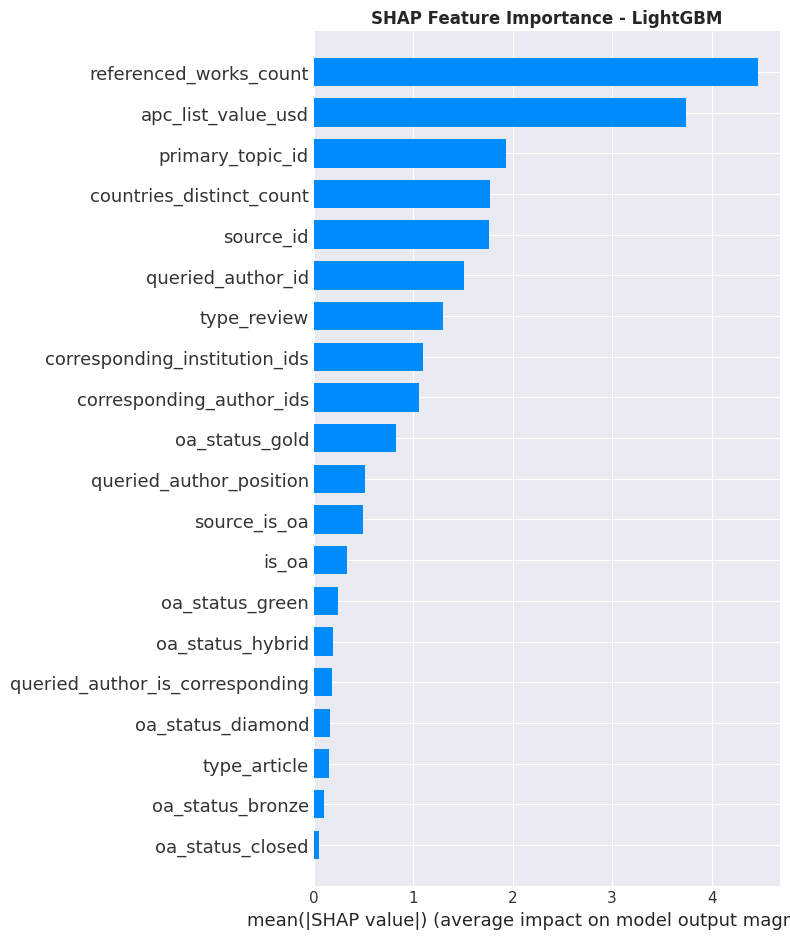

✓ SHAP Bar plot complete


In [193]:
print("=" * 70)
print(f"SHAP ANALYSIS: {best_model_row['Model']} ({best_model_row['Strategy']})")
print("=" * 70)

# Prefer the tuned pipeline when the handoff cell has been executed.
if 'use_tuned_pipeline' in globals() and use_tuned_pipeline and 'best_tuned_model' in globals():
    tuned_preprocessor = best_tuned_model.named_steps['preprocess']
    best_model = best_tuned_model.named_steps['model']
    X_test_shap = tuned_preprocessor.transform(X_test_pipe)
    y_test_shap = y_test_pipe.to_numpy()
    shap_feature_names = list(tuned_preprocessor.get_feature_names_out())
    shap_source_note = f"Using tuned pipeline features from {best_tuned_model_name}"
else:
    # Prepare SHAP data based on best model strategy from the untuned comparison.
    if best_strategy == 'Random 80/20':
        X_test_shap = X_test_s1_model
        y_test_shap = y_test_s1
        shap_feature_names = list(feature_names_model_s1)
    else:  # Stratified
        X_test_shap = X_test_s3_model
        y_test_shap = y_test_s3
        shap_feature_names = list(feature_names_model_s3)
    shap_source_note = f"Using untuned comparison split: {best_strategy}"

print(shap_source_note)

# Initialize SHAP explainer (TreeExplainer for tree-based models)
if isinstance(best_model, xgb.XGBRegressor):
    explainer = shap.TreeExplainer(best_model)
elif isinstance(best_model, lgb.LGBMRegressor):
    explainer = shap.TreeExplainer(best_model)
elif isinstance(best_model, CatBoostRegressor):
    explainer = shap.TreeExplainer(best_model)
else:
    # For other models, use KernelExplainer
    explainer = shap.KernelExplainer(best_model.predict, shap.sample(X_test_shap, 50))

# Compute SHAP values
print("Computing SHAP values...")
shap_values = explainer.shap_values(X_test_shap)

# Convert to numpy array if it's a list (common for CatBoost)
if isinstance(shap_values, list):
    shap_values = np.array(shap_values)
shap_values = np.asarray(shap_values, dtype=np.float64)
print("✓ SHAP values computed")

# Summary plot: Bar chart of average |SHAP| per feature
print("\nGenerating SHAP summary plot (bar)...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_shap, feature_names=shap_feature_names, plot_type='bar', show=False)
plt.title(f"SHAP Feature Importance - {best_model_row['Model']}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ SHAP Bar plot complete")


Generating feature vs target correlation plots for top 5 SHAP features...


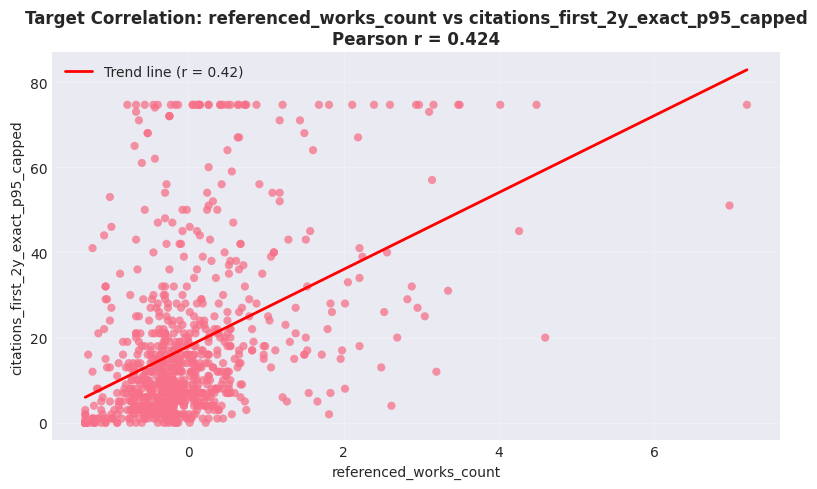

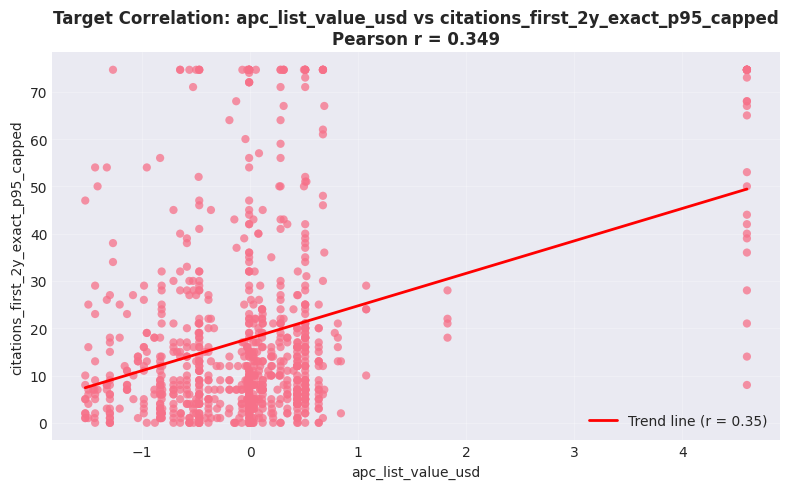

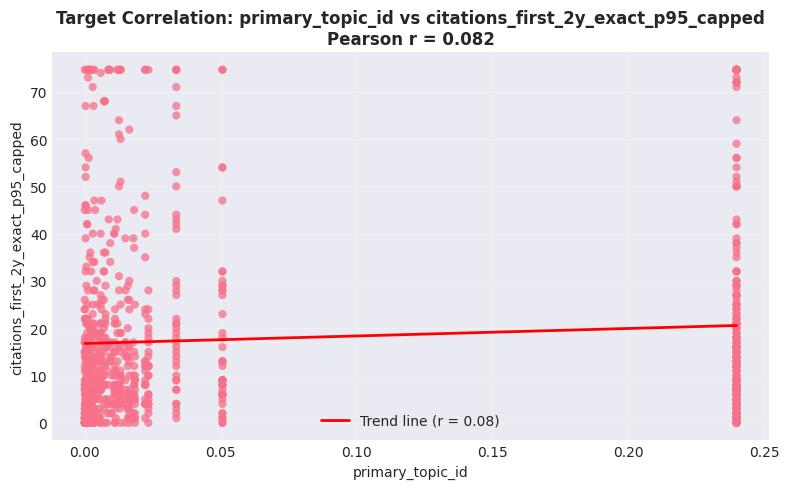

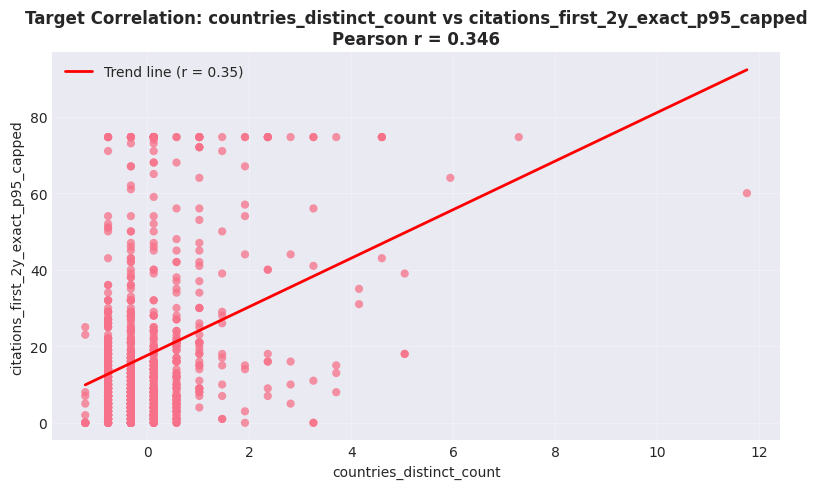

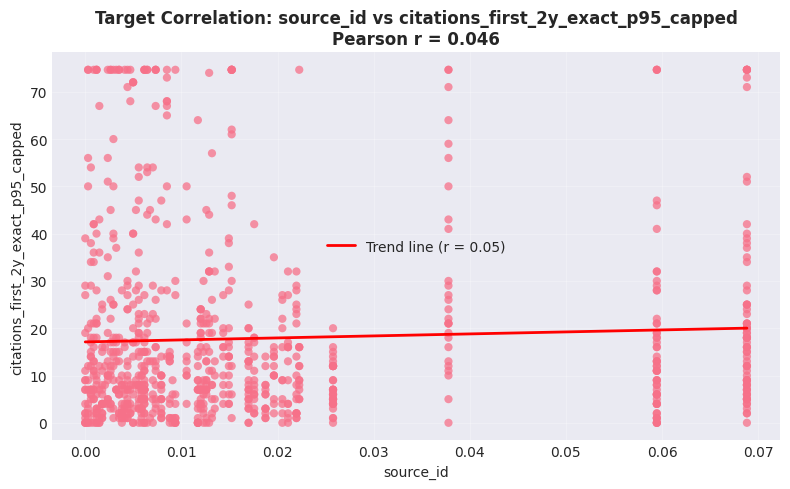

✓ Feature-vs-target correlation plots complete for top 5 SHAP features: ['referenced_works_count', 'apc_list_value_usd', 'primary_topic_id', 'countries_distinct_count', 'source_id']


In [194]:
# Correlation plots for top 5 SHAP features (Y-axis = target variable)
print("\nGenerating feature vs target correlation plots for top 5 SHAP features...")

# Keep feature names aligned with the SHAP matrix source (tuned or untuned flow).
active_feature_names = shap_feature_names if 'shap_feature_names' in globals() else feature_names

# Identify top 5 features by mean absolute SHAP value
mean_shap_vals = np.abs(shap_values).mean(axis=0)
top_5_indices = np.argsort(mean_shap_vals)[-5:][::-1]
top_5_features = [active_feature_names[i] for i in top_5_indices]

# Numeric arrays for robust plotting
X_test_shap_numeric = np.asarray(X_test_shap, dtype=np.float64)
y_target = np.asarray(y_test_shap, dtype=np.float64)

for feature_idx in top_5_indices:
    x_feature = X_test_shap_numeric[:, feature_idx]

    # Keep only finite values
    valid_mask = np.isfinite(x_feature) & np.isfinite(y_target)
    x_clean = x_feature[valid_mask]
    y_clean = y_target[valid_mask]

    if len(x_clean) < 2:
        print(f"Skipping {active_feature_names[feature_idx]} (not enough valid points).")
        continue

    # Pearson correlation
    corr = np.corrcoef(x_clean, y_clean)[0, 1]

    plt.figure(figsize=(8, 5))
    plt.scatter(x_clean, y_clean, alpha=0.75, s=35, edgecolors='none')

    # Add regression/trend line when feature has variation
    if np.std(x_clean) > 0:
        slope, intercept = np.polyfit(x_clean, y_clean, 1)
        x_line = np.linspace(x_clean.min(), x_clean.max(), 200)
        y_line = slope * x_line + intercept
        plt.plot(x_line, y_line, color='red', linewidth=2, label=f"Trend line (r = {corr:.2f})")
        plt.legend(loc='best')

    plt.xlabel(active_feature_names[feature_idx])
    plt.ylabel(TARGET)
    plt.title(
        f"Target Correlation: {active_feature_names[feature_idx]} vs {TARGET}\n"
        f"Pearson r = {corr:.3f}",
        fontsize=12,
        fontweight='bold'
    )
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

print(f"✓ Feature-vs-target correlation plots complete for top 5 SHAP features: {top_5_features}")


Generating SHAP summary plot (violin)...


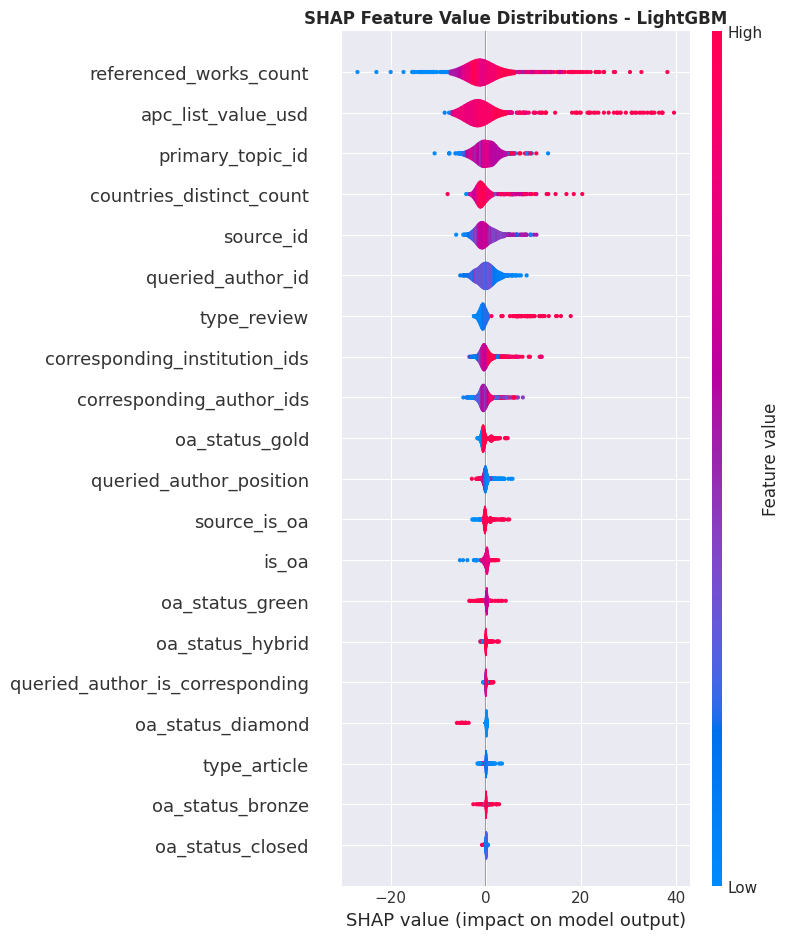

✓ SHAP Violin plot complete

Generating SHAP waterfall plot for single prediction...


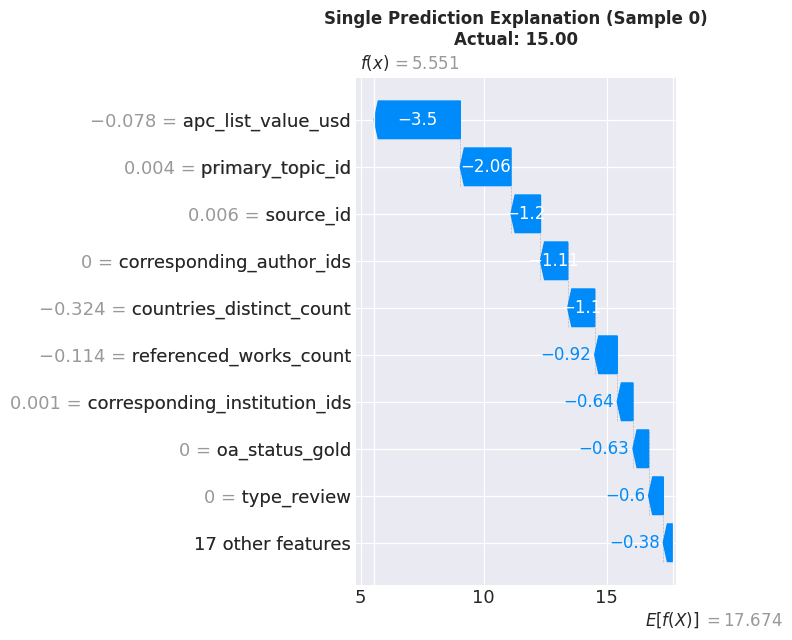

✓ SHAP Waterfall plot complete


In [195]:
# Summary plot: Violin chart of SHAP value distributions
print("\nGenerating SHAP summary plot (violin)...")
plt.figure(figsize=(10, 8))

active_feature_names = shap_feature_names if 'shap_feature_names' in globals() else feature_names

# For violin plot, we need numeric X_test_shap - convert if necessary
X_test_shap_numeric = np.asarray(X_test_shap, dtype=np.float64)

try:
    shap.summary_plot(shap_values, X_test_shap_numeric, feature_names=active_feature_names, plot_type='violin', show=False)
except TypeError:
    # If violin plot fails due to data type issues, use force plot as fallback
    print("Violin plot encountered data type issues. Using force plot instead...")
    plt.clf()
    fig = plt.figure(figsize=(10, 8))
    shap.force_plot(explainer.expected_value, shap_values[:50], X_test_shap_numeric[:50], 
                    feature_names=active_feature_names, matplotlib=True, show=False)

plt.title(f"SHAP Feature Value Distributions - {best_model_row['Model']}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ SHAP Violin plot complete")

# Single prediction: Waterfall plot for first test sample
print("\nGenerating SHAP waterfall plot for single prediction...")
sample_idx = 0
plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap.Explanation(values=shap_values[sample_idx], 
                                      base_values=explainer.expected_value,
                                      data=X_test_shap_numeric[sample_idx],
                                      feature_names=active_feature_names), show=False)
plt.title(f"Single Prediction Explanation (Sample {sample_idx})\nActual: {y_test_shap[sample_idx]:.2f}", 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ SHAP Waterfall plot complete")

## Section 9: Random Forest Validation

Train a Random Forest as a parallel model to cross-check feature importance rankings against gradient boosted models.

In [196]:
print("=" * 70)
print("RANDOM FOREST VALIDATION MODEL")
print("=" * 70)
print("Training Random Forest on Strategy 1 (Random 80/20) split for comparison...")

# Train Random Forest on same split as best model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=6,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_s1_model, y_train_s1)

# Evaluate Random Forest
y_pred_rf = rf_model.predict(X_test_s1_model)
mae_rf = mean_absolute_error(y_test_s1, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_s1, y_pred_rf))
r2_rf = r2_score(y_test_s1, y_pred_rf)

print(f"\nRandom Forest Performance:")
print(f"  MAE:  {mae_rf:.4f}")
print(f"  RMSE: {rmse_rf:.4f}")
print(f"  R²:   {r2_rf:.4f}")

# Extract feature importance from Random Forest
rf_importance = rf_model.feature_importances_
rf_importance_normalized = rf_importance / rf_importance.sum()

print(f"\nTop 10 features by Random Forest importance:")
rf_top_indices = np.argsort(rf_importance)[-10:][::-1]
for rank, idx in enumerate(rf_top_indices, 1):
    print(f"  {rank:2d}. {feature_names_model_s1[idx]:30s} = {rf_importance_normalized[idx]:.4f}")

print("\n✓ Random Forest validation complete")

RANDOM FOREST VALIDATION MODEL
Training Random Forest on Strategy 1 (Random 80/20) split for comparison...

Random Forest Performance:
  MAE:  10.0317
  RMSE: 14.3467
  R²:   0.4547

Top 10 features by Random Forest importance:
   1. referenced_works_count         = 0.3585
   2. apc_list_value_usd             = 0.2743
   3. countries_distinct_count       = 0.0883
   4. type_review                    = 0.0804
   5. primary_topic_id               = 0.0555
   6. source_id                      = 0.0543
   7. corresponding_institution_ids  = 0.0224
   8. corresponding_author_ids       = 0.0187
   9. queried_author_id              = 0.0179
  10. type_article                   = 0.0058

✓ Random Forest validation complete


## Section 10: Feature Importance Comparison Across All Models

In [197]:
print("=" * 70)
print("FEATURE IMPORTANCE COMPARISON")
print("=" * 70)

from sklearn.inspection import permutation_importance

# Keep feature names aligned with the active SHAP matrix.
active_feature_names = (
    shap_feature_names
    if 'shap_feature_names' in globals()
    else (feature_names_model_s1 if 'feature_names_model_s1' in globals() else feature_names)
 )

if 'use_tuned_pipeline' in globals() and use_tuned_pipeline and 'best_tuned_model' in globals():
    print("Mode: tuned pipeline comparison (same feature space for fair interpretation).")

    perm_result = permutation_importance(
        best_tuned_model,
        X_test_pipe,
        y_test_pipe,
        n_repeats=8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    perm_importance = perm_result.importances_mean
    perm_importance_norm = perm_importance / (perm_importance.sum() + 1e-12)

    shap_importance = np.abs(shap_values).mean(axis=0)
    shap_importance_norm = shap_importance / (shap_importance.sum() + 1e-12)

    # Defensive alignment in case lengths differ after preprocessing updates
    n_common = min(len(active_feature_names), len(perm_importance_norm), len(shap_importance_norm))
    importance_comparison = pd.DataFrame({
        'Feature': active_feature_names[:n_common],
        'Permutation': perm_importance_norm[:n_common],
        'SHAP': shap_importance_norm[:n_common],
    })

    for col in ['Permutation', 'SHAP']:
        importance_comparison[f'{col}_Rank'] = importance_comparison[col].rank(ascending=False)
    importance_comparison['Avg_Rank'] = importance_comparison[['Permutation_Rank', 'SHAP_Rank']].mean(axis=1)

    importance_comparison_sorted = importance_comparison.sort_values('Avg_Rank')

    print("\nTOP 15 FEATURES (Permutation + SHAP, tuned model):")
    print(importance_comparison_sorted[['Feature', 'Permutation', 'SHAP', 'Avg_Rank']].head(15).to_string(index=False))

    print("\nBOTTOM 10 FEATURES (low joint importance):")
    print(importance_comparison_sorted[['Feature', 'Permutation', 'SHAP', 'Avg_Rank']].tail(10).to_string(index=False))

else:
    print("Mode: untuned model-family comparison (XGBoost/LightGBM/CatBoost/RandomForest + SHAP).")

    # Extract feature importances from untuned family models
    xgb_importance = xgb_s1.feature_importances_
    lgb_importance = lgb_s1.feature_importances_
    cb_importance = cb_s1.feature_importances_
    rf_importance_norm_copy = rf_importance_normalized.copy()

    # Normalize importances
    xgb_importance_norm = xgb_importance / (xgb_importance.sum() + 1e-12)
    lgb_importance_norm = lgb_importance / (lgb_importance.sum() + 1e-12)
    cb_importance_norm = cb_importance / (cb_importance.sum() + 1e-12)
    shap_importance = np.abs(shap_values).mean(axis=0)
    shap_importance_norm = shap_importance / (shap_importance.sum() + 1e-12)

    n_common = min(
        len(active_feature_names),
        len(xgb_importance_norm),
        len(lgb_importance_norm),
        len(cb_importance_norm),
        len(rf_importance_norm_copy),
        len(shap_importance_norm),
    )

    importance_comparison = pd.DataFrame({
        'Feature': active_feature_names[:n_common],
        'XGBoost': xgb_importance_norm[:n_common],
        'LightGBM': lgb_importance_norm[:n_common],
        'CatBoost': cb_importance_norm[:n_common],
        'RandomForest': rf_importance_norm_copy[:n_common],
        'SHAP': shap_importance_norm[:n_common],
    })

    for col in ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'SHAP']:
        importance_comparison[f'{col}_Rank'] = importance_comparison[col].rank(ascending=False)

    importance_comparison['Avg_Rank'] = importance_comparison[[
        'XGBoost_Rank', 'LightGBM_Rank', 'CatBoost_Rank', 'RandomForest_Rank', 'SHAP_Rank'
    ]].mean(axis=1)

    importance_comparison_sorted = importance_comparison.sort_values('Avg_Rank')

    print("\nTOP 15 FEATURES (sorted by average rank across all models):")
    print(importance_comparison_sorted[['Feature', 'XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'SHAP', 'Avg_Rank']].head(15).to_string(index=False))

    print("\nBOTTOM 10 FEATURES (likely noise or weak signals):")
    print(importance_comparison_sorted[['Feature', 'XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'SHAP', 'Avg_Rank']].tail(10).to_string(index=False))

FEATURE IMPORTANCE COMPARISON
Mode: tuned pipeline comparison (same feature space for fair interpretation).

TOP 15 FEATURES (Permutation + SHAP, tuned model):
                        Feature  Permutation     SHAP  Avg_Rank
         referenced_works_count     0.058781 0.203458       2.5
               primary_topic_id     0.048251 0.087934       4.0
             apc_list_value_usd     0.028015 0.170335       4.5
                      source_id     0.013078 0.080442       7.5
               oa_status_bronze     0.359278 0.004846       7.5
              oa_status_diamond     0.325765 0.007187       7.5
                          is_oa     0.038061 0.015083       8.5
               oa_status_closed     0.066358 0.002359       9.0
       countries_distinct_count     0.000000 0.080721       9.5
              queried_author_id     0.001947 0.068844       9.5
                   source_is_oa     0.018420 0.022494       9.5
queried_author_is_corresponding     0.025346 0.008210      10.0
        

In [198]:
# Ranking correlation analysis (Spearman correlation)
from scipy.stats import spearmanr

print("\n" + "=" * 70)
print("RANKING CORRELATION (Spearman) ACROSS IMPORTANCE SOURCES")
print("=" * 70)

if {'Permutation_Rank', 'SHAP_Rank'}.issubset(set(importance_comparison.columns)):
    corr, pvalue = spearmanr(importance_comparison['Permutation_Rank'], importance_comparison['SHAP_Rank'])
    corr_df_processed = pd.DataFrame([[1.0, corr], [corr, 1.0]], 
                           index=['Permutation', 'SHAP'], 
                           columns=['Permutation', 'SHAP'])
    print(corr_df_processed.round(3).to_string())
    print(f"\nSpearman rho (Permutation vs SHAP): {corr:.3f} | p-value: {pvalue:.3e}")
else:
    rank_cols = ['XGBoost_Rank', 'LightGBM_Rank', 'CatBoost_Rank', 'RandomForest_Rank', 'SHAP_Rank']
    model_names_for_corr = ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'SHAP']

    # Compute Spearman correlations
    correlation_matrix = np.zeros((5, 5))
    for i, model1 in enumerate(rank_cols):
        for j, model2 in enumerate(rank_cols):
            corr, _ = spearmanr(importance_comparison[model1], importance_comparison[model2])
            correlation_matrix[i, j] = corr

    corr_df_processed = pd.DataFrame(correlation_matrix, 
                           index=model_names_for_corr, 
                           columns=model_names_for_corr)
    print(corr_df_processed.round(3).to_string())

print("\nInterpretation:")
print("  • Values close to 1.0 = strong agreement between importance rankings")
print("  • Values close to 0   = disagreement (potential instability or model-specific patterns)")
print("  • High correlations confirm that importance signals are robust")


RANKING CORRELATION (Spearman) ACROSS IMPORTANCE SOURCES
             Permutation   SHAP
Permutation        1.000 -0.389
SHAP              -0.389  1.000

Spearman rho (Permutation vs SHAP): -0.389 | p-value: 1.515e-01

Interpretation:
  • Values close to 1.0 = strong agreement between importance rankings
  • Values close to 0   = disagreement (potential instability or model-specific patterns)
  • High correlations confirm that importance signals are robust



Visualizing feature importance alignment...


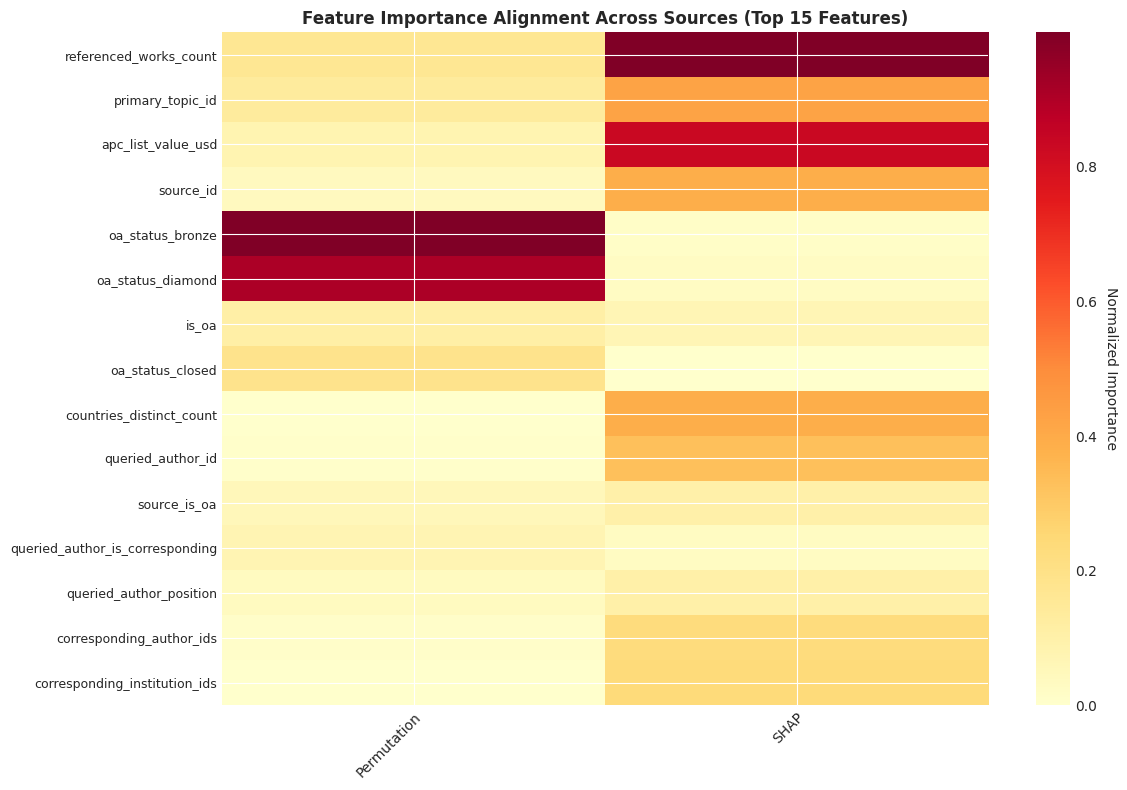

✓ Feature importance comparison complete


In [199]:
# Visualization: Feature importance heatmap for top features
print("\nVisualizing feature importance alignment...")

importance_cols = [c for c in ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'Permutation', 'SHAP'] if c in importance_comparison.columns]
top_n = 20 if len(importance_comparison) >= 20 else len(importance_comparison)
top_features_plot = importance_comparison_sorted.head(top_n).copy()

fig, ax = plt.subplots(figsize=(12, 8))

# Create heatmap data
heatmap_data = top_features_plot[importance_cols].values

# Normalize by column (each source scaled to 0-1)
heatmap_data_normalized = (heatmap_data - heatmap_data.min(axis=0)) / (heatmap_data.max(axis=0) - heatmap_data.min(axis=0) + 1e-8)

im = ax.imshow(heatmap_data_normalized, cmap='YlOrRd', aspect='auto')

# Set ticks and labels
ax.set_xticks(np.arange(len(importance_cols)))
ax.set_yticks(np.arange(len(top_features_plot)))
ax.set_xticklabels(importance_cols)
ax.set_yticklabels(top_features_plot['Feature'].values, fontsize=9)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Normalized Importance', rotation=270, labelpad=15)

ax.set_title(f'Feature Importance Alignment Across Sources (Top {top_n} Features)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Feature importance comparison complete")

## Section 11: Train-Test Strategy Comparison & Analysis

In [200]:
print("=" * 100)
print("TRAIN-TEST STRATEGY COMPARISON")
print("=" * 100)

# Focus on best main models: XGBoost, LightGBM, CatBoost across both strategies
strategy_comparison = results_summary[results_summary['Model'].isin(['XGBoost', 'LightGBM', 'CatBoost'])].copy()

print("\nPerformance by Strategy:")
print(strategy_comparison.to_string(index=False))

# Pivot for easier comparison
strategy_pivot_r2 = strategy_comparison.pivot(index='Model', columns='Strategy', values='R²')
strategy_pivot_mae = strategy_comparison.pivot(index='Model', columns='Strategy', values='MAE')
strategy_pivot_rmse = strategy_comparison.pivot(index='Model', columns='Strategy', values='RMSE')

print("\n" + "=" * 70)
print("R² SCORE BY STRATEGY:")
print("=" * 70)
print(strategy_pivot_r2.round(4).to_string())

print("\n" + "=" * 70)
print("STRATEGY ANALYSIS & RECOMMENDATIONS:")
print("=" * 70)

if 'Random 80/20' in strategy_pivot_r2.columns:
    print("\n1. RANDOM 80/20 SPLIT")
    print("   ✓ Pros: Standard practice; balanced sampling; reproducible")
    print("   ✗ Cons: May leak temporal patterns (mixing past & future citations)")
    print("   → Best for: Baseline comparison; understanding overall model capability")
    print(f"   → Avg R² across main models: {strategy_pivot_r2['Random 80/20'].mean():.4f}")

if 'Stratified' in strategy_pivot_r2.columns:
    print("\n2. STRATIFIED SPLIT (By publication topic)")
    print("   ✓ Pros: Ensures balanced representation of key groups; robust across topics")
    print("   ✗ Cons: No temporal validation; may overfit to group patterns")
    print("   → Best for: Confirming features generalize across publication domains")
    print(f"   → Avg R² across main models: {strategy_pivot_r2['Stratified'].mean():.4f}")

# Performance variance across strategies
print("\n" + "=" * 70)
print("MODEL PERFORMANCE STABILITY ACROSS STRATEGIES:")
print("=" * 70)

stability = pd.DataFrame({
    'Model': strategy_pivot_r2.index,
    'R² Range': strategy_pivot_r2.max(axis=1) - strategy_pivot_r2.min(axis=1),
    'R² Std Dev': strategy_pivot_r2.std(axis=1),
    'R² CoeffVar': (strategy_pivot_r2.std(axis=1) / strategy_pivot_r2.mean(axis=1)).round(3)
})

print(stability.to_string(index=False))
print("\nInterpretation:")
print("  • Low CoeffVar = stable performance across strategies (robust model)")
print("  • High CoeffVar = sensitive to train-test split choice (may overfit to specific data distribution)")

TRAIN-TEST STRATEGY COMPARISON

Performance by Strategy:
   Model     Strategy      MAE      RMSE       R²
 XGBoost Random 80/20 9.089037 13.304470 0.531069
 XGBoost   Stratified 9.089037 13.304470 0.531069
LightGBM Random 80/20 9.368456 13.623801 0.508288
LightGBM   Stratified 9.368456 13.623801 0.508288
CatBoost Random 80/20 9.855210 14.155143 0.469186
CatBoost   Stratified 9.855210 14.155143 0.469186

R² SCORE BY STRATEGY:
Strategy  Random 80/20  Stratified
Model                             
CatBoost        0.4692      0.4692
LightGBM        0.5083      0.5083
XGBoost         0.5311      0.5311

STRATEGY ANALYSIS & RECOMMENDATIONS:

1. RANDOM 80/20 SPLIT
   ✓ Pros: Standard practice; balanced sampling; reproducible
   ✗ Cons: May leak temporal patterns (mixing past & future citations)
   → Best for: Baseline comparison; understanding overall model capability
   → Avg R² across main models: 0.5028

2. STRATIFIED SPLIT (By publication topic)
   ✓ Pros: Ensures balanced representation 

## Section 11.5: Overfitting vs Underfitting Diagnostics (Best Model)

This section adds regression-appropriate diagnostics for the active best model.

- AUC/ROC is not used because the target is continuous (regression), not a classification label.
- We focus on train-test generalization gap, cross-validation stability, learning curves, and residual behavior.

OVERFITTING / UNDERFITTING DIAGNOSTICS
Active best model: LightGBM
Evaluation split: Random 80/20 (pipeline tuned)

Split      MAE    MedAE      RMSE    RMSLE       R²
Train 4.150792 2.966835  5.938320 0.506106 0.903925
 Test 9.302903 6.092411 13.525134 0.857716 0.515385

Generalization diagnosis:
- R² gap (train - test): 0.3885
- RMSE ratio (test/train): 2.2776
- Status: Likely overfitting (high variance): strong train-test performance gap.

5-Fold CV summary (train split only):
Metric   CV Mean   CV Std
   MAE  9.830745 0.419916
  RMSE 14.253329 0.741532
    R²  0.443359 0.031280


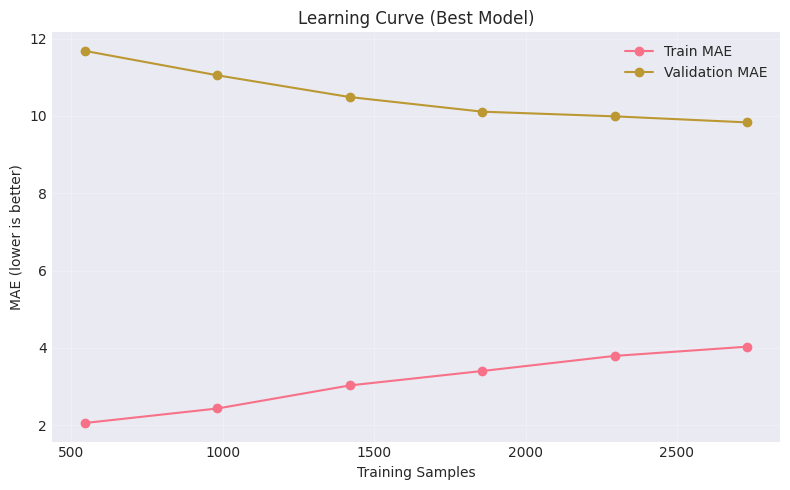

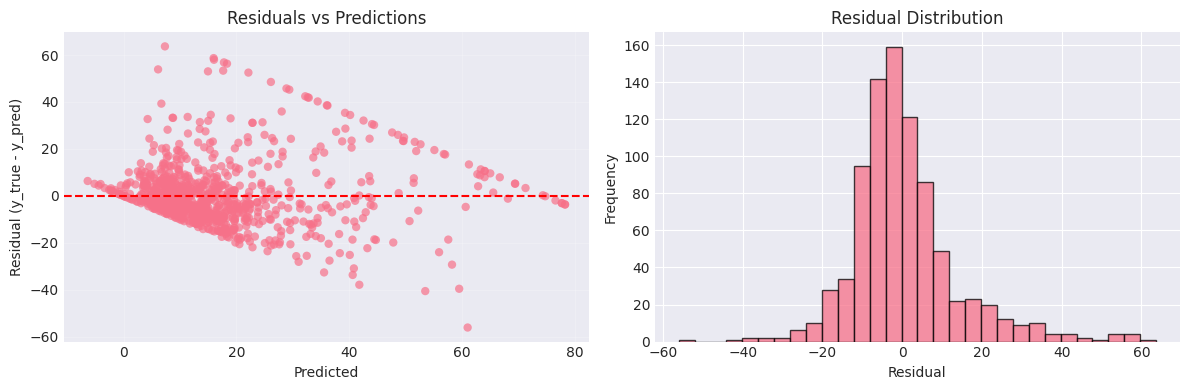


✓ Overfitting/underfitting diagnostics completed


In [201]:
from sklearn.base import clone
from sklearn.model_selection import KFold, cross_validate, learning_curve
from sklearn.metrics import median_absolute_error

print("=" * 100)
print("OVERFITTING / UNDERFITTING DIAGNOSTICS")
print("=" * 100)

def _safe_rmsle(y_true, y_pred):
    y_true = np.maximum(np.asarray(y_true, dtype=float), 0.0)
    y_pred = np.maximum(np.asarray(y_pred, dtype=float), 0.0)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

# Resolve active model/data path
if 'use_tuned_pipeline' in globals() and use_tuned_pipeline and 'best_tuned_model' in globals():
    active_model = best_tuned_model
    X_train_diag, X_test_diag = X_train_pipe, X_test_pipe
    y_train_diag, y_test_diag = y_train_pipe, y_test_pipe
    active_model_name = best_tuned_model_name
    active_split_name = 'Random 80/20 (pipeline tuned)'
else:
    active_model = best_model
    if best_strategy == 'Random 80/20':
        X_train_diag, X_test_diag = X_train_s1, X_test_s1
        y_train_diag, y_test_diag = y_train_s1, y_test_s1
    else:
        X_train_diag, X_test_diag = X_train_s3, X_test_s3
        y_train_diag, y_test_diag = y_train_s3, y_test_s3
    active_model_name = str(best_model_row['Model'])
    active_split_name = best_strategy

# Train predictions vs test predictions
train_pred = active_model.predict(X_train_diag)
test_pred = active_model.predict(X_test_diag)

metrics_diag = pd.DataFrame([
    {
        'Split': 'Train',
        'MAE': mean_absolute_error(y_train_diag, train_pred),
        'MedAE': median_absolute_error(y_train_diag, train_pred),
        'RMSE': np.sqrt(mean_squared_error(y_train_diag, train_pred)),
        'RMSLE': _safe_rmsle(y_train_diag, train_pred),
        'R²': r2_score(y_train_diag, train_pred),
    },
    {
        'Split': 'Test',
        'MAE': mean_absolute_error(y_test_diag, test_pred),
        'MedAE': median_absolute_error(y_test_diag, test_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test_diag, test_pred)),
        'RMSLE': _safe_rmsle(y_test_diag, test_pred),
        'R²': r2_score(y_test_diag, test_pred),
    },
])

print(f"Active best model: {active_model_name}")
print(f"Evaluation split: {active_split_name}\n")
print(metrics_diag.to_string(index=False))

# Generalization-gap heuristics
gap_r2 = float(metrics_diag.loc[metrics_diag['Split'] == 'Train', 'R²'].iloc[0] - metrics_diag.loc[metrics_diag['Split'] == 'Test', 'R²'].iloc[0])
gap_rmse_ratio = float(metrics_diag.loc[metrics_diag['Split'] == 'Test', 'RMSE'].iloc[0] / (metrics_diag.loc[metrics_diag['Split'] == 'Train', 'RMSE'].iloc[0] + 1e-12))

if (metrics_diag.loc[1, 'R²'] < 0.20) and (metrics_diag.loc[0, 'R²'] < 0.30):
    fit_status = 'Likely underfitting (high bias): low explanatory power in both train and test.'
elif (gap_r2 > 0.15) or (gap_rmse_ratio > 1.30):
    fit_status = 'Likely overfitting (high variance): strong train-test performance gap.'
else:
    fit_status = 'Reasonable bias-variance balance for current feature set and split.'

print("\nGeneralization diagnosis:")
print(f"- R² gap (train - test): {gap_r2:.4f}")
print(f"- RMSE ratio (test/train): {gap_rmse_ratio:.4f}")
print(f"- Status: {fit_status}")

# Cross-validation on train split for stability
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2',
}

cv_model = clone(active_model)
cv_results = cross_validate(
    cv_model,
    X_train_diag,
    y_train_diag,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    return_train_score=False,
    error_score='raise',
)

cv_summary = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'CV Mean': [
        -cv_results['test_mae'].mean(),
        -cv_results['test_rmse'].mean(),
        cv_results['test_r2'].mean(),
    ],
    'CV Std': [
        cv_results['test_mae'].std(),
        cv_results['test_rmse'].std(),
        cv_results['test_r2'].std(),
    ],
})

print("\n5-Fold CV summary (train split only):")
print(cv_summary.to_string(index=False))

# Learning curve (MAE)
train_sizes, train_scores, val_scores = learning_curve(
    estimator=clone(active_model),
    X=X_train_diag,
    y=y_train_diag,
    train_sizes=np.linspace(0.2, 1.0, 6),
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    shuffle=True,
    random_state=RANDOM_STATE,
    error_score='raise',
)

train_mae_curve = -train_scores.mean(axis=1)
val_mae_curve = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mae_curve, marker='o', label='Train MAE')
plt.plot(train_sizes, val_mae_curve, marker='o', label='Validation MAE')
plt.xlabel('Training Samples')
plt.ylabel('MAE (lower is better)')
plt.title('Learning Curve (Best Model)')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Residual diagnostics
residuals_test = np.asarray(y_test_diag) - np.asarray(test_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(test_pred, residuals_test, alpha=0.7, edgecolors='none')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual (y_true - y_pred)')
axes[0].set_title('Residuals vs Predictions')
axes[0].grid(alpha=0.2)

axes[1].hist(residuals_test, bins=30, edgecolor='black', alpha=0.75)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

# Store diagnostics for final summary cell
diagnostics_summary = {
    'active_model_name': active_model_name,
    'active_split_name': active_split_name,
    'r2_gap': gap_r2,
    'rmse_ratio_test_train': gap_rmse_ratio,
    'fit_status': fit_status,
    'test_mae': float(metrics_diag.loc[metrics_diag['Split'] == 'Test', 'MAE'].iloc[0]),
    'test_rmse': float(metrics_diag.loc[metrics_diag['Split'] == 'Test', 'RMSE'].iloc[0]),
    'test_r2': float(metrics_diag.loc[metrics_diag['Split'] == 'Test', 'R²'].iloc[0]),
    'cv_r2_mean': float(cv_summary.loc[cv_summary['Metric'] == 'R²', 'CV Mean'].iloc[0]),
    'cv_r2_std': float(cv_summary.loc[cv_summary['Metric'] == 'R²', 'CV Std'].iloc[0]),
}

print("\n✓ Overfitting/underfitting diagnostics completed")

## Section 12: Final Summary & Recommendations

In [202]:
print("=" * 100)
print("FINAL SUMMARY & RECOMMENDATIONS")
print("=" * 100)

print("\nBEST PERFORMING MODEL")
print("-" * 70)
print(f"Model: {best_model_row['Model']}")
print(f"Strategy: {best_model_row['Strategy']}")
print(f"R² Score: {best_model_row['R²']:.4f}")
print(f"MAE: {best_model_row['MAE']:.4f}")
print(f"RMSE: {best_model_row['RMSE']:.4f}")

if 'diagnostics_summary' in globals():
    print("\nGENERALIZATION DIAGNOSTIC (Overfitting / Underfitting)")
    print("-" * 70)
    print(f"Active model analyzed: {diagnostics_summary['active_model_name']}")
    print(f"Evaluation split: {diagnostics_summary['active_split_name']}")
    print(f"Test R²: {diagnostics_summary['test_r2']:.4f}")
    print(f"Test MAE: {diagnostics_summary['test_mae']:.4f}")
    print(f"Test RMSE: {diagnostics_summary['test_rmse']:.4f}")
    print(f"CV R² mean ± std: {diagnostics_summary['cv_r2_mean']:.4f} ± {diagnostics_summary['cv_r2_std']:.4f}")
    print(f"R² gap (train - test): {diagnostics_summary['r2_gap']:.4f}")
    print(f"RMSE ratio (test/train): {diagnostics_summary['rmse_ratio_test_train']:.4f}")
    print(f"Diagnosis: {diagnostics_summary['fit_status']}")

print("\nTOP 10 MOST IMPORTANT FEATURES")
print("-" * 70)

importance_metric_cols = [c for c in ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'Permutation', 'SHAP'] if c in importance_comparison_sorted.columns]

top10 = importance_comparison_sorted.head(10).copy()
for rank, (_, row) in enumerate(top10.iterrows(), 1):
    avg_importance = row[importance_metric_cols].mean() if len(importance_metric_cols) > 0 else np.nan
    print(f"{rank:2d}. {row['Feature'][:50]:50s} -> Avg Importance: {avg_importance:.4f}")

print("\nFEATURES WITH LOW/INCONSISTENT IMPORTANCE")
print("-" * 70)

rank_cols_dynamic = [c for c in importance_comparison.columns if c.endswith('_Rank')]
if rank_cols_dynamic:
    importance_comparison['Rank_StdDev'] = importance_comparison[rank_cols_dynamic].std(axis=1)
    unstable_features = importance_comparison[
        importance_comparison['Rank_StdDev'] > importance_comparison['Rank_StdDev'].quantile(0.75)
    ].copy()
    print(f"Found {len(unstable_features)} features with inconsistent importance across sources:")
    cols_to_show = [c for c in ['Feature', 'Avg_Rank', 'Rank_StdDev'] if c in unstable_features.columns]
    print(unstable_features[cols_to_show].head(5).to_string(index=False))
else:
    print("Insufficient ranking columns to compute consistency spread.")

print("\nRECOMMENDATIONS")
print("-" * 70)
print(f"1. Production candidate: {best_model_row['Model']} with {best_model_row['Strategy']} strategy")
print("2. Keep the overfitting/underfitting diagnostics section as mandatory before each model refresh.")
print("3. Prefer reporting MAE, RMSE, R² and RMSLE for this regression target (AUC/ROC is not applicable).")
print("4. Track stability: rerun the stratified evaluation when new publication cohorts are added.")
print("5. If overfitting signs increase, reduce model complexity or strengthen regularization before adding features.")

print("\n" + "=" * 100)
print("PIPELINE COMPLETE")
print("=" * 100)

FINAL SUMMARY & RECOMMENDATIONS

BEST PERFORMING MODEL
----------------------------------------------------------------------
Model: LightGBM
Strategy: Tuned pipeline (Random 80/20)
R² Score: 0.5154
MAE: 9.3029
RMSE: 13.5251

GENERALIZATION DIAGNOSTIC (Overfitting / Underfitting)
----------------------------------------------------------------------
Active model analyzed: LightGBM
Evaluation split: Random 80/20 (pipeline tuned)
Test R²: 0.5154
Test MAE: 9.3029
Test RMSE: 13.5251
CV R² mean ± std: 0.4434 ± 0.0313
R² gap (train - test): 0.3885
RMSE ratio (test/train): 2.2776
Diagnosis: Likely overfitting (high variance): strong train-test performance gap.

TOP 10 MOST IMPORTANT FEATURES
----------------------------------------------------------------------
 1. referenced_works_count                             -> Avg Importance: 0.1311
 2. primary_topic_id                                   -> Avg Importance: 0.0681
 3. apc_list_value_usd                                 -> Avg Importance: